---
---

#  Eine Analyse mit dem V-Dem Datensatz zur Identifikation von Faktoren der politischen Instabilität
---
---

<div class="alert alert-block alert-warning">
Adapt the headline in the cell above!
</div>

<div class="alert alert-block alert-warning">

Present a short summary of the pitch!

(Add up to 5 bullet points in the cell below)
</div>

*  Politische Instabilität stellt ein erhebliches Risiko für Länder und die globale Sicherheit dar. Eine frühzeitige Erkennung ist wichtig 
* Das Ziel des Projektes ist die Entdeckung länderspezifischer Stereotypen im Hinblick auf ihre politische Stabilität durch eine explorative Datenanalyse

* Regierungen und internationale Organisationen können dadurch gezielter präventive Maßnahmen in Risikoländern 
ergreifen, weil sie die Faktoren, an denen etwas 
geändert werden muss, kennen

* Der V-Dem-Datensatz bietet zahlreiche Daten zu politischer 
Instabilität, Demokratiequalität, Wirtschaft, Bildung und sozialen 
Indikatoren auf Intervallskalenniveau, die das Clustern und Erkennen 
von Ländergruppen ermöglichen


# Imports and Settings
---
<div class="alert alert-block alert-warning">
Use the following code cell to organize all imports and global settings.
Do not remove the pandas option.
    
(Commented code, in the next cell)
</div>

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [60]:
# make pandas display ALL columns of a dataframe
pd.options.display.max_columns = None

# Task 1 -- The Data

<div class="alert alert-block alert-warning">
Present the origin of the dataset, including e.g.
    
* the source where you got it from (link to the repository),
* the author(s),
* the license,
* the purpose for which it was collected!

(Add bullet points in the cell below)
</div>

## Herkunft des Datensatzes: V-Dem Institut (Varieties of Democracy)

- **Quelle**: [V-Dem Project – Official Website](https://www.v-dem.net/)
- **Autoren**: Das V-Dem-Projekt wird geleitet von der V-Dem-Institution unter der Koordination von Staffan I. Lindberg (University of Gothenburg) und einem internationalen Team von Politikwissenschaftler:innen.
- **Lizenz**: Der Datensatz ist unter der [Creative Commons Attribution-NonCommercial-NoDerivatives 4.0 International License (CC BY-NC-ND 4.0)](https://creativecommons.org/licenses/by-nc-nd/4.0/) veröffentlicht. Quelle: https://github.com/vdeminstitute/vdemdata/releases
- **Zweck der Datenerhebung**:  
  Der Datensatz wird jährlich erhoben, um detaillierte und vergleichbare Informationen über Demokratie, politische Institutionen und Menschenrechte in nahezu allen Ländern der Welt über einen langen historischen Zeitraum zu ermöglichen. Er richtet sich insbesondere an Forscher:innen, politische Analyst:innen und Institutionen zur Bewertung demokratischer Entwicklungen weltweit.


## The Raw Data
<div class="alert alert-block alert-warning"> 

Load the data and present a couple of samples. Call the dataset variable __raw_data__.

(Commented code, add cells below)
</div>


In [61]:
raw_data = pd.read_csv("data\V-Dem-CY-Full+Others-v15.csv")

C:\Users\Dell\AppData\Local\Temp\ipykernel_2180\3939445217.py:1: DtypeWarning: Columns (364,365,366,399,804,836,837,924,1240,1257,1486,3094,3168,3169,3341,3342,3344,3345,3347,3350,3352) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_data = pd.read_csv("data\V-Dem-CY-Full+Others-v15.csv")


In [62]:
# Überblick über Struktur und Spalten
print(raw_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27913 entries, 0 to 27912
Columns: 4607 entries, country_name to e_pt_coup_attempts
dtypes: float64(4560), int64(18), object(29)
memory usage: 981.1+ MB
None


In [63]:
# gibt 5 Zufällige Spalten aus
raw_data.sample(5)

country_name country_text_id  country_id  year historical_date  \
2008           Egypt             EGY          13  1904      1904-12-31   
755      Switzerland             CHE           6  1956      1956-12-31   
23783    New Zealand             NZL         185  1888      1888-12-31   
17689  Guinea-Bissau             GNB         119  1949      1949-12-31   
26669        Bavaria             BVR         350  1861      1861-12-31   

       project  historical                                        histname  \
2008         2           1  Part of Ottoman Empire under British influence   
755          0           1                             Swiss Confederation   
23783        1           1                              New Zealand Colony   
17689        0           0                     Colony of Portuguese Guinea   
26669        1           1                              Kingdom of Bavaria   

       codingstart  codingend  codingstart_contemp  codingend_contemp  \
2008          1789       2024               1900.0             2024.0   
755           1798       2024               1900.0             2024.0   
23783         1841       2024               1900.0             2024.0   
17689         1900       2024               1900.0             2024.0   
26669         1789       1871                  NaN                NaN   

       codingstart_hist  codingend_hist  gapstart1  gapstart2  gapstart3  \
2008             1789.0          1920.0        NaN        NaN        NaN   
755              1798.0          1920.0        NaN        NaN        NaN   
23783            1841.0          1920.0        NaN        NaN        NaN   
17689               NaN             NaN        NaN        NaN        NaN   
26669            1789.0          1871.0        NaN        NaN        NaN   

       gapend1  gapend2  gapend3  gap_index  COWcode  v2x_polyarchy  \
2008       NaN      NaN      NaN         11    651.0          0.116   
755        NaN      NaN      NaN          4    225.0          0.617   
23783      NaN      NaN      NaN        190    920.0          0.571   
17689      NaN      NaN      NaN        126    404.0          0.007   
26669      NaN      NaN      NaN        212    245.0          0.181   

       v2x_polyarchy_codelow  v2x_polyarchy_codehigh  v2x_polyarchy_sd  \
2008                   0.092                   0.135             0.022   
755                    0.590                   0.643             0.028   
23783                  0.536                   0.615             0.041   
17689                  0.003                   0.009             0.004   
26669                  0.154                   0.205             0.026   

       v2x_libdem  v2x_libdem_codelow  v2x_libdem_codehigh  v2x_libdem_sd  \
2008        0.168               0.147                0.187          0.020   
755         0.562               0.536                0.591          0.028   
23783       0.503               0.467                0.540          0.037   
17689       0.013               0.005                0.018          0.008   
26669       0.165               0.138                0.191          0.026   

       v2x_partipdem  v2x_partipdem_codelow  v2x_partipdem_codehigh  \
2008           0.034                  0.021                   0.045   
755            0.525                  0.501                   0.551   
23783          0.341                  0.308                   0.384   
17689          0.012                  0.002                   0.018   
26669          0.037                  0.020                   0.047   

       v2x_partipdem_sd  v2x_delibdem  v2x_delibdem_codelow  \
2008              0.014         0.118                 0.075   
755               0.027         0.587                 0.565   
23783             0.037           NaN                   NaN   
17689             0.010         0.004                 0.000   
26669             0.015           NaN                   NaN   

       v2x_delibdem_codehigh  v2x_delibdem_sd  v2x_egalde

In [64]:
# Ich habe direkt zum Anfang eine Auswahl von Spalten getroffen von denen ich denke, dass diese relevant sein könnten. 
# Da der Datansatz über 4000 Spalten besitzt, war dies nötig. Für die Aufgaben wären 4000 Spalten sehr unhandlich. 
# Als Kommentar markierte Variablen enthielten zu viele NaNs, weshalb ich mich nachträglich entschieden habe diese später nicht in den "Data"-DF aufzunehmen. 

relevante_spalten = [ 
    "country_name",      # Land
    "year",              # Jahr
    "e_wbgi_pve",        # politische Stabilität
    "v2x_libdem",        # Liberale Demokratie (Index)
    "v2x_polyarchy",     # Wahlen (Index)
    "v2x_freexp_altinf", # Meinungs- und Informationsfreiheit (Index)
    "v2xcl_rol",         # Rechtsstaatlichkeit (Index)
    "v2xcl_acjst",       # Zugang zur Justiz
    "v2x_rule",          # Rule of Law (Index)
    "v2x_pubcorr",       # öffentliche Korruption
    "v2x_corr",          # politische Korruption
    "v2x_execorr",       # Korruption der Exekutive
   # "e_cow_exports",    # Exporte
   # "e_cow_imports",    # Importe
   # "e_gdp",            # BIP
   # "e_miinflat",       # Inflation
    "e_miferrat",        # Fertilitätsrate
    "e_pelifeex",        # Lebenserwartung
   # "e_civil_war",      # Bürgerkrieg
    "v2cacamps_mean",    # politische Polarisierung
    "v2caviol_mean",     # politische Gewalt
    "v2caassemb_mean",   # Versammlungsfreiheit
    "v2cagenmob_mean",   # Massenmobilisierung
    "v2caautmob_mean",   # Autokratische Bewegungen
    "v2cademmob_mean",   # Demokratische Bewegungen
    "v2castate_mean",    # Beteiligung an staatlich organisierten Gruppen
    "v2canonpol_mean",   # Beteiligung an unabhängigen nicht-politischen Gruppen
    "v2cafres_mean"      # Freiheit von Forschung und Lehre
]

relevante_spalten = raw_data[relevante_spalten]

In [65]:
# Daten von 2019 bis 2024 filtern 
letzten_fünf_jahre = relevante_spalten[
    relevante_spalten["year"].between(2019, 2024)
]

letzten_fünf_jahre.sample(5)

,country_name,year,e_wbgi_pve,v2x_libdem,v2x_polyarchy,v2x_freexp_altinf,v2xcl_rol,v2xcl_acjst,v2x_rule,v2x_pubcorr,v2x_corr,v2x_execorr,e_miferrat,e_pelifeex,v2cacamps_mean,v2caviol_mean,v2caassemb_mean,v2cagenmob_mean,v2caautmob_mean,v2cademmob_mean,v2castate_mean,v2canonpol_mean,v2cafres_mean
25196,Saudi Arabia,2021,-0.591,0.045,0.015,0.088,0.178,0.283,0.344,0.529,0.381,0.545,2.17,74.17,1.778,1.000,0.333,0.111,0.111,0.111,1.111,1.667,0.778
21612,Equatorial Guinea,2023,NaN,0.053,0.184,0.170,0.213,0.308,0.045,0.809,0.867,0.939,4.08,66.33,2.625,1.500,1.000,1.250,1.625,0.250,2.250,1.375,0.875
3741,Bangladesh,2022,-1.092,0.095,0.263,0.379,0.353,0.316,0.077,0.961,0.918,0.795,2.18,75.47,3.250,3.000,1.250,2.250,2.000,2.500,1.750,1.500,1.750
6943,Nigeria,2019,-1.933,0.364,0.525,0.871,0.617,0.843,0.268,0.897,0.934,0.887,4.86,64.34,2.167,3.364,2.000,2.455,1.000,2.364,1.455,3.182,3.455
6833,Lebanon,2020,-1.621,0.277,0.440,0.724,0.594,0.549,0.294,0.792,0.767,0.694,2.31,75.26,2.778,2.556,2.444,3.333,1.111,3.333,2.000,2.000,2.889


<div class="alert alert-block alert-warning"> 
Explain the dataset with all its features.
    
* The features should be described in the following table. The range is the set of possible values that a feature can take, e.g. "red, green, blue", "$\mathbb{R}$", "$1,2,...,12$".
* You may describe each feature individually or groups of features, if many features are similar (whatever is easier to explain.)

(Fill in the table, add bullet points in the next cell)
</div>

* Viele Variablen wurden ursprünglich z.B. durch Expertenmeinungen ordinalskaliert erhoben. Anschließend wurden diese Daten in Intervallskalen überführt (Oft auch durch die Bildung von Mittelwerten). Der Datensatz enthält daher Zusätze wie _ord oder _mean, die verschiedene Skalenniveaus abdecken. Für meine Zwecke werde ich immer Daten nutzen, die auf Intervallskalenniveau vorhanden sind. Neben Daten die auf dem Intervalskalenniveau (meist 0-4) erhoben wurden, gibt es auch indexvariablen, die sich aus verschiedenen Variablen zusammensetzen. Diese haben eine Range von 0-1. 



| Feature                 | Wertebereich     | Erklärung                                                             |
| ----------------------- | ---------------- | --------------------------------------------------------------------- |
| **country\_name**       | Länder (Strings) | Name des Landes                                                       |
| **year**                | 1789 – 2024      | Jahr der Messung                                                      |
| **e\_wbgi\_pve**        | ℝ (ca. -4 bis 2) | Indikator für politische Stabilität (World Bank Governance Indicator) |
| **v2x\_libdem**         | \[0, 1]          | Index für liberale Demokratie                                         |
| **v2x\_polyarchy**      | \[0, 1]          | Index für wahlbasierte Demokratie (Polyarchie)                        |
| **v2x\_freexp\_altinf** | \[0, 1]          | Grad der Meinungs- und Informationsfreiheit                           |
| **v2xcl\_rol**          | \[0, 1]          | Rechtsstaatlichkeit (Rule of Law)                                     |
| **e\_cow\_exports**     | ℝ⁺ (%)           | Exportquote am BIP                                                    |
| **e\_cow\_imports**     | ℝ⁺ (%)           | Importquote am BIP                                                    |
| **e\_gdp**              | ℝ⁺               | Bruttoinlandsprodukt pro Kopf (meist in USD, ggf. logarithmiert)      |
| **e\_miinflat**         | ℝ                | Jährliche Inflationsrate                                              |
| **e\_miferrat**         | ℝ⁺               | Fertilitätsrate (Kinder pro Frau)                                     |
| **e\_pelifeex**         | ℝ⁺               | Lebenserwartung bei Geburt (in Jahren)                                |
| **e\_civil\_war**       | {0, 1}           | Bürgerkrieg im Jahr vorhanden (1 = ja)                                |
| **v2cacamps\_mean**     | \[0, 4]          | Politische Polarisierung                                              |
| **v2caviol\_mean**      | \[0, 4]          | Politische Gewalt (Experteneinschätzung)                              |
| **v2caassemb\_mean**    | \[0, 4]          | Versammlungsfreiheit (Einschätzung)                                   |
| **v2cagenmob\_mean**    | \[0, 4]          | Mobilisierung durch Protestbewegungen                                 |
| **v2caautmob\_mean**    | \[0, 4]          | Autokratische soziale Bewegungen                                      |
| **v2cademmob\_mean**    | \[0, 4]          | Demokratische soziale Bewegungen                                      |
| **v2castate\_mean**     | \[0, 4]          | Fähigkeit des Staates, Autorität auszuüben                            |
| **v2canonpol\_mean**    | \[0, 4]          | Aktivität nichtpolitischer Organisationen                             |
| **v2cafres\_mean**      | \[0, 4]          | Ausmaß staatlicher Repression                                         |



<div class="alert alert-block alert-warning">
Explain why the dataset is suitable for the pitched task!
    
(Add up 3 bullet points in the cell below)
</div>

 * Der V-Dem-Datensatz bietet zahlreiche Daten zu politischer 
Instabilität, Demokratiequalität, Wirtschaft, Bildung und sozialen 
Indikatoren auf Intervallskalenniveau, die das Clustern und Erkennen 
von Ländergruppen ermöglichen.
 * Eine Erstellung von Stereotypen durch verschiedene Clusteranalysen 
bezüglich der Variable der politischen Stabilität (und anderen) ist 
möglich. 
* Es könnten bezüglich der Variablen Gemeinsamkeiten und 
Zusammenhänge gefunden werden

# Task 2 -- Initial Data Analysis

<div class="alert alert-block alert-warning"> 
<b>Initial Data Analysis (IDA)</b>: Present relevant quantities about the data.
    
(Commented Code + bullet points, add cells below)
</div>

In [66]:
# Anzahl der Zeilen und Spalten
raw_data.shape

(27913, 4607)

In [67]:
# Alle Länder zählen
# ISO 3166-1 führt 249 Ländercodes, inklusive abhängiger Gebiete und Sonderverwaltungszonen. 
# Allgemein sind aber nur 195 Länder anerkannt. 
raw_data["country_name"].nunique()

202

In [68]:
# Statistische Kennzahlen für numerische Spalten
relevante_spalten.describe()

,year,e_wbgi_pve,v2x_libdem,v2x_polyarchy,v2x_freexp_altinf,v2xcl_rol,v2xcl_acjst,v2x_rule,v2x_pubcorr,v2x_corr,v2x_execorr,e_miferrat,e_pelifeex,v2cacamps_mean,v2caviol_mean,v2caassemb_mean,v2cagenmob_mean,v2caautmob_mean,v2cademmob_mean,v2castate_mean,v2canonpol_mean,v2cafres_mean
count,27913.000000,4123.000000,25530.000000,26775.000000,27377.000000,27795.000000,27704.000000,27525.000000,27369.000000,27020.000000,27217.000000,25317.000000,25317.000000,19351.000000,19351.000000,19351.000000,19351.000000,19351.000000,19351.000000,19351.000000,19351.000000,15334.000000
mean,1929.594096,-0.172125,0.221204,0.262252,0.419814,0.452601,0.454321,0.494517,0.418088,0.437213,0.450636,4.950780,49.980994,2.141164,1.580044,2.061208,1.572736,0.876191,1.221901,1.344312,1.821385,2.335071
std,64.943165,0.970291,0.231332,0.262190,0.310917,0.304654,0.295420,0.299099,0.292767,0.282463,0.306358,1.857389,17.034862,0.788667,0.827137,1.102813,0.791944,0.781859,0.770945,0.879376,0.712600,0.997057
min,1789.000000,-3.313000,0.005000,0.006000,0.010000,0.000000,0.002000,0.005000,0.001000,0.002000,0.003000,0.710000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1881.000000,-0.771000,0.057000,0.055000,0.132000,0.173000,0.202000,0.233000,0.145000,0.175000,0.154000,3.400000,34.400000,1.571000,1.000000,1.200000,1.000000,0.250000,0.667000,0.667000,1.333000,1.571000
50%,1940.000000,-0.094000,0.124000,0.167000,0.350000,0.412000,0.415000,0.460000,0.416000,0.438000,0.445000,5.600000,47.190000,2.167000,1.500000,2.000000,1.500000,0.714000,1.125000,1.200000,1.750000,2.400000
75%,1985.000000,0.594000,0.296000,0.371000,0.710000,0.721000,0.693000,0.762000,0.676000,0.690000,0.726000,6.470000,66.030000,2.714000,2.143000,3.000000,2.125000,1.333000,1.714000,1.875000,2.333000,3.200000
max,2024.000000,1.759000,0.897000,0.923000,0.989000,0.993000,0.996000,0.999000,0.990000,0.971000,0.981000,8.860000,85.500000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000



### fehlende Werte

* Die Analyse von fehlenden Werten hinsichtlich relevanter Variablen ist besonders wichtig für mein Projekt. 
Die Länder lassen sich nur vernünftig Clustern, wenn es genug Daten gibt. Ich muss wissen, welche Häufigkeiten bezüglich einer Variable je Land existieren.
* Ein Weiterer Punkt ist, dass die Erhebung der Variablen unterschiedliche Start und Endzeitpunkte haben kann, sodass sich die Datenabdeckung je nach Zeitraum erheblich verändern kann. 
* Ich möchte primär Wissen wie sich die Datenabdeckung der Zielvariable e_wbgi_pve (politische Stabilität) verhält und in welchem Zeitraum und in Welchen Ländern die erklärenden Variablen  eine Clusteranalyse zulassen.  

In [69]:
# Überblick über fehlende Werte jeder Spalte
fehlende_werte = relevante_spalten.isnull().sum()
fehlende_werte

country_name             0
year                     0
e_wbgi_pve           23790
v2x_libdem            2383
v2x_polyarchy         1138
v2x_freexp_altinf      536
v2xcl_rol              118
v2xcl_acjst            209
v2x_rule               388
v2x_pubcorr            544
v2x_corr               893
v2x_execorr            696
e_miferrat            2596
e_pelifeex            2596
v2cacamps_mean        8562
v2caviol_mean         8562
v2caassemb_mean       8562
v2cagenmob_mean       8562
v2caautmob_mean       8562
v2cademmob_mean       8562
v2castate_mean        8562
v2canonpol_mean       8562
v2cafres_mean        12579
dtype: int64

In [70]:
# Datenabdeckung checken
# Für jede Spalte zählen, wie viele Nicht-Null-Werte pro Land vorhanden sind
datenabdeckung = relevante_spalten.groupby("country_name").count()
datenabdeckung

,year,e_wbgi_pve,v2x_libdem,v2x_polyarchy,v2x_freexp_altinf,v2xcl_rol,v2xcl_acjst,v2x_rule,v2x_pubcorr,v2x_corr,v2x_execorr,e_miferrat,e_pelifeex,v2cacamps_mean,v2caviol_mean,v2caassemb_mean,v2cagenmob_mean,v2caautmob_mean,v2cademmob_mean,v2castate_mean,v2canonpol_mean,v2cafres_mean
country_name,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,236,24,236,236,236,236,236,236,236,236,236,225,225,125,125,125,125,125,125,125,125,93
Albania,113,24,111,111,113,113,113,113,113,113,113,113,113,113,113,113,113,113,113,113,113,74
Algeria,125,24,125,125,125,125,125,125,125,125,125,125,125,125,125,125,125,125,125,125,125,125
Angola,125,24,125,125,125,125,125,125,125,125,125,125,125,125,125,125,125,125,125,125,125,63
Argentina,236,24,236,236,236,236,236,236,236,236,236,225,225,125,125,125,125,125,125,125,125,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Würtemberg,83,0,57,57,83,83,83,83,83,83,83,0,0,0,0,0,0,0,0,0,0,0
Yemen,169,24,169,169,169,169,169,169,169,169,169,158,158,107,107,107,107,107,107,107,107,55
Zambia,114,24,114,114,114,114,114,114,114,114,114,114,114,114,114,114,114,114,114,114,114,62


In [71]:
# Datenabdeckung der letzten jahre
filtered = relevante_spalten[relevante_spalten["year"].between(1996, 2022)]

# Danach Gruppierung und Zählung der Nicht-Null-Werte je Land und Spalte
datenabdeckung1 = filtered.groupby("country_name").count()

# Ergebnis anzeigen
datenabdeckung1.head() 

,year,e_wbgi_pve,v2x_libdem,v2x_polyarchy,v2x_freexp_altinf,v2xcl_rol,v2xcl_acjst,v2x_rule,v2x_pubcorr,v2x_corr,v2x_execorr,e_miferrat,e_pelifeex,v2cacamps_mean,v2caviol_mean,v2caassemb_mean,v2cagenmob_mean,v2caautmob_mean,v2cademmob_mean,v2castate_mean,v2canonpol_mean,v2cafres_mean
country_name,,,,,,,,,,,,,,,,,,,,,,
Afghanistan,27,24,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27
Albania,27,24,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27
Algeria,27,24,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27
Angola,27,24,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27
Argentina,27,24,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27,27


Wichtige Erkenntnisse: 
* Es gibt keine Informationen bezüglich der politischen Stabilität zu Palestine/Gaza, zu Palestine/ Westbank, zu Hong Kong, zum Kosovo, zum Somaliland und zu Sansibar
* Die allermeisten Länder haben einen Erhebungszeitraum von 1996 bis 2022 --> Es werden nicht mehr Daten wenn man den Zeitraum erweitert. Obwohl der Zeitraum 27 Jahre umfasst, haben die meisten Länder 24 einträge, weshalb die Erhebung scheinbar 3 mal ausgesetzt worden ist. Die Daten zu einigen wenigen Ländern wurden zudem seltener als 24 mal erhoben. Der SüdSudan wurden nur 12 mal erhoben. Timor-Leste 21 mal, Serbia und Montenegro 17 mal. 
* In vielen Anderen Variablen erscheint die Datendichte gut zu sein. Jedoch nicht in allen Variablen. So weist die Variable zum Civilwar, die Variable zum Import, die Variable zum Export und die Variable zur Inflation auf ein paar defizite hin. # --> habe ich nachträglich entfernt. Daher tauchen diese hier gar nicht mehr auf. 

# Task 3 -- Preprocessing

<div class="alert alert-block alert-warning"> 
Conduct all steps of Task 3. Call the result "data".
    
(Commented code + bullet points, add cells below)
</div>

* Ich möchte direkt wissen wofür die einzelnen Spaltennamen stehen. --> Umbenennen
* Ich möchte einen Datensatz mit einer möglichst hohen Datendichte, der die letzten Jahrzehnte abbildet. 
* Das Problem ist, dass einige wenige Länder weniger Daten enthalten als andere. Die Spalten sollten jedoch für jedes Land gleichviele Daten bereitsstellen.  
* Natürlich könnte man nur Daten aus einem Jahr nehmen und hätte dann einen ausgewogenen Datensatz. Jedoch erwarte ich eine bessere und fundiertere Analyse, wenn auch die Vergangenheit analysiert wird. 
* Da kein Land im Jahr 1997, 1999, 2001, 2023 und 2024 angaben bezüglich der Hauptvariable (politische Stabilität) besitzt, möchte ich diese Zeilen löschen.
* Ferner sollen auch Länderzeilen denen kein Wert bezüglich der Spalte der politischen Stabilität zugeordnet ist gelöscht werden. 
* Bei Ländern mit weniger Werten habe ich lange überlegt, ob man eine Spline-Interpolation verwenden könnte. Eine Spline-Interpolation würde dafür sorgen, dass möglichst realistische Verläufe zwischen den Zeitreihenwerten erzeugt werden. Wenn aber mehrere aufeinander folgende Werte fehlen, dann funktioniert dies nicht. Weil das immer der Fall war, habe ich mich dazu entschieden diese Länder ebenso rauszulöschen.

* Bezüglich der anderen Variablen kann es ebenso vorkommen, dass es nicht gleichviele Zeilen je Land gibt bzw.. das einige Länder gar nicht vertreten sind, weshalb einge wenige Länder schwächer ins Gewicht fallen könnten. Da dies bei einigen Variablen sehr extrem war, habe ich mich entschieden diese Variablen zu löschen bzw.. gar nicht erst zu laden. 


In [72]:
# Umbenennen der Spaltennamen

Test = filtered.rename(columns={
    "country_name": "Land",
    "year": "Jahr",
    "e_wbgi_pve": "politische Stabilität",
    "v2x_libdem": "Liberale Demokratie (Index)",
    "v2x_polyarchy": "Wahlen (Index)",
    "v2x_freexp_altinf": "Meinungs- und Informationsfreiheit (Index)",
    "v2xcl_rol": "Gleicheit vor dem Gesetz und individuelle Freiheiten (Index)",
    "v2xcl_acjst": "Zugang zur Justiz",
    "v2x_rule": "Rechtsstaatlichkeit(Index)",
    "v2x_pubcorr": "öffentliche Korruption",
    "v2x_corr": "politische Korruption",
    "v2x_execorr": "Korruption der Exekutive",
    "e_cow_exports": "Exporte",
    "e_cow_imports": "Importe",
    "e_gdp": "BIP",
    "e_miinflat": "Inflation",
    "e_miferrat": "Fertilitätsrate",
    "e_pelifeex": "Lebenserwartung",
    "e_civil_war": "Bürgerkrieg",
    "v2cacamps_mean": "politische Polarisierung",
    "v2caviol_mean": "politische Gewalt",
    "v2caassemb_mean": "Versammlungsfreiheit",
    "v2cagenmob_mean": "Massenmobilisierung",
    "v2caautmob_mean": "Autokratische Bewegungen",
    "v2cademmob_mean": "Demokratische Bewegungen",
    "v2castate_mean": "Beteiligung an staatlich organisierten Gruppen",
    "v2canonpol_mean": "Beteiligung an unabhängigen nicht-politischen Gruppen",
    "v2cafres_mean": "Freiheit von Forschung und Lehre"
})


In [73]:
# Löschen der besagten Jahreszeilen
Test_cleaned = Test[~Test["Jahr"].isin([1997, 1999, 2001, 2023, 2024])]

In [74]:
# Länderzeilen aufgrund mangelhafter Daten löschen. 
# ertellen einer Liste dieser Länder
raus = ["Palestine/Gaza","Palestine/West Bank", "Hong Kong","Kosovo","Somaliland","Zanzibar", "South Sudan","Timor-Leste", "Serbia", "Montenegro"]

# Entfernen der  Zeilen aus dem DF. ~ ist das Zeichen für Negation. Es bleiben also alle anderen Zeilen enthalten. 
Test = Test_cleaned[~Test_cleaned["Land"].isin(raus)]

In [75]:
Data = Test.dropna()

In [76]:
Data = Test

* Vorstellen der relevanten Kenngrößen, des veränderten finalen DFs.

In [77]:
# Der DF besitzt 4044 Zeilen und 28 Spalten
Data.shape

(4056, 23)

In [78]:
# Insgesamt 26342 Einträge
Data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4056 entries, 207 to 26342
Data columns (total 23 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   Land                                                          4056 non-null   object 
 1   Jahr                                                          4056 non-null   int64  
 2   politische Stabilität                                         4056 non-null   float64
 3   Liberale Demokratie (Index)                                   4053 non-null   float64
 4   Wahlen (Index)                                                4056 non-null   float64
 5   Meinungs- und Informationsfreiheit (Index)                    4056 non-null   float64
 6   Gleicheit vor dem Gesetz und individuelle Freiheiten (Index)  4056 non-null   float64
 7   Zugang zur Justiz                                             4056 non-

In [79]:
# Übersicht über deskriptive Statistiken 
Data.describe()

,Jahr,politische Stabilität,Liberale Demokratie (Index),Wahlen (Index),Meinungs- und Informationsfreiheit (Index),Gleicheit vor dem Gesetz und individuelle Freiheiten (Index),Zugang zur Justiz,Rechtsstaatlichkeit(Index),öffentliche Korruption,politische Korruption,Korruption der Exekutive,Fertilitätsrate,Lebenserwartung,politische Polarisierung,politische Gewalt,Versammlungsfreiheit,Massenmobilisierung,Autokratische Bewegungen,Demokratische Bewegungen,Beteiligung an staatlich organisierten Gruppen,Beteiligung an unabhängigen nicht-politischen Gruppen,Freiheit von Forschung und Lehre
count,4056.000000,4056.000000,4053.000000,4056.000000,4056.000000,4056.000000,4056.000000,4056.000000,4056.000000,4050.000000,4056.000000,4056.000000,4056.000000,4056.000000,4056.000000,4056.000000,4056.000000,4056.000000,4056.000000,4056.000000,4056.000000,4019.000000
mean,2010.250000,-0.167449,0.406576,0.520684,0.666696,0.672943,0.644289,0.538478,0.490025,0.508454,0.500248,2.979643,70.129347,2.107071,1.414087,2.661791,1.890246,0.866105,1.538420,1.552790,2.215050,2.694397
std,7.339445,0.970768,0.271479,0.264959,0.287130,0.269890,0.272511,0.315094,0.308145,0.307292,0.308742,1.584126,8.806495,0.756997,0.876376,1.056803,0.775173,0.761628,0.827402,0.865055,0.594851,0.936470
min,1996.000000,-3.313000,0.005000,0.015000,0.012000,0.006000,0.024000,0.010000,0.001000,0.002000,0.003000,0.780000,32.520000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,0.000000
25%,2004.750000,-0.772000,0.150000,0.283000,0.504750,0.492000,0.431750,0.257000,0.182000,0.202000,0.197250,1.710000,64.167500,1.600000,0.714000,1.857000,1.333000,0.250000,0.909000,0.875000,1.833000,2.100000
50%,2010.500000,-0.092500,0.371000,0.525500,0.759000,0.741000,0.699000,0.541500,0.543000,0.562500,0.580000,2.460000,71.840000,2.143000,1.300000,2.900000,1.889000,0.667000,1.500000,1.571000,2.222000,2.889000
75%,2016.250000,0.605000,0.653000,0.772000,0.896000,0.909000,0.892000,0.859250,0.748000,0.785000,0.753250,4.080000,76.810000,2.667000,2.000000,3.571000,2.429000,1.302000,2.133000,2.167000,2.600000,3.429000
max,2022.000000,1.759000,0.897000,0.923000,0.989000,0.993000,0.996000,0.999000,0.990000,0.971000,0.980000,7.840000,85.230000,4.000000,4.000000,4.000000,4.000000,3.667000,4.000000,3.857000,3.889000,4.000000


* Datendichte

In [80]:
# Entscheidend ist wie viele Länder die gleiche Anzahl an Einträgen je Spalte haben. 
# Der Code soll folgendes Aussagen: z.B. in Der Spalte Liberale Demokratie (Index) haben 168 Länder 24 Einträge und ein Land 21 Einträge.

for spalte in Data.columns: # Schleife die durch alle Columns des Dfs Data iteriert
        print(Data.groupby("Land")[spalte].count().value_counts(), "\n") 
        
        # Zuerst wird nach Land gruppiert. Dann wir auf jede Spalte zugegriffen und die Enträge gezählt. 
        # value_counts zählt dann, wie oft jede mögliche Anzahl von Werten für die Länder vorkommt. 
        # 0 müsste bedeuten, z.B. bei Exporte, dass es zu drei Ländern keine Daten gibt. 

Land
24    169
Name: count, dtype: int64 

Jahr
24    169
Name: count, dtype: int64 

politische Stabilität
24    169
Name: count, dtype: int64 

Liberale Demokratie (Index)
24    168
21      1
Name: count, dtype: int64 

Wahlen (Index)
24    169
Name: count, dtype: int64 

Meinungs- und Informationsfreiheit (Index)
24    169
Name: count, dtype: int64 

Gleicheit vor dem Gesetz und individuelle Freiheiten (Index)
24    169
Name: count, dtype: int64 

Zugang zur Justiz
24    169
Name: count, dtype: int64 

Rechtsstaatlichkeit(Index)
24    169
Name: count, dtype: int64 

öffentliche Korruption
24    169
Name: count, dtype: int64 

politische Korruption
24    168
18      1
Name: count, dtype: int64 

Korruption der Exekutive
24    169
Name: count, dtype: int64 

Fertilitätsrate
24    169
Name: count, dtype: int64 

Lebenserwartung
24    169
Name: count, dtype: int64 

politische Polarisierung
24    169
Name: count, dtype: int64 

politische Gewalt
24    169
Name: count, dtype: int64 

Ver

In [81]:
# Überblick über fehlende Werte! --> Export, Import, inflation, BIP und Bürgerkrieg sind schlecht. Variablen raus?
fehlende_werte1 = Data.isnull().sum()
fehlende_werte1

Land                                                             0
Jahr                                                             0
politische Stabilität                                            0
Liberale Demokratie (Index)                                      3
Wahlen (Index)                                                   0
Meinungs- und Informationsfreiheit (Index)                       0
Gleicheit vor dem Gesetz und individuelle Freiheiten (Index)     0
Zugang zur Justiz                                                0
Rechtsstaatlichkeit(Index)                                       0
öffentliche Korruption                                           0
politische Korruption                                            6
Korruption der Exekutive                                         0
Fertilitätsrate                                                  0
Lebenserwartung                                                  0
politische Polarisierung                                      

In [82]:
Data = Data.dropna()
# Es ist vertretbar die paar Zeilen zu löschen. 

# Task 4 -- Exploratory Data Analysis

<div class="alert alert-block alert-warning"> 
Present 3 highlights from the exploratory data analysis in your draft.

(Commented code + bullet points, add cells below under the respective hightlight headlines)

In der Final-Stage sollen nur die Highlights vorgestellt werden. 

## EDA Highlight 1

# Korrelationen zwischen Faktoren und politischer Stabilität
* Ich möchte wissen welche Variablen den stärksten Einfluss bzw. Zusammenhang mit der politischen Stabilität haben.     Dazu möchte ich alle Variablen mit der Zielvariable korrellieren lassen. Dadurch kann man später gezielter nach  Clustern suchen und weiß welche variablen relevant sein werden. 

In [83]:
# Liste aller relevanten Variablen --> alle außer "Land" und "Jahr" und politische Stabilität selbst
# politische stabilität muss enthalten sein, weil man diese Variable zur Berechnung braucht.
relevante_variablen = [
    'Liberale Demokratie (Index)', 'Wahlen (Index)', 'Meinungs- und Informationsfreiheit (Index)',
    'Gleicheit vor dem Gesetz und individuelle Freiheiten (Index)', 'Zugang zur Justiz',
    'öffentliche Korruption', 'politische Korruption', 'Korruption der Exekutive',
    
  #  'Exporte', 'Importe', 'BIP', 'Inflation',  'Bürgerkrieg',
    'Fertilitätsrate', 'Lebenserwartung', 'politische Polarisierung', 'politische Gewalt',"Rechtsstaatlichkeit(Index)",
    'Versammlungsfreiheit', 'Massenmobilisierung', 'Autokratische Bewegungen',
    'Demokratische Bewegungen', 'Beteiligung an staatlich organisierten Gruppen',
    'Beteiligung an unabhängigen nicht-politischen Gruppen', 'Freiheit von Forschung und Lehre',
    "politische Stabilität"
]

In [84]:
# Korrelation jeder Variable mit "politische Stabilität"
Korrelationen = Data[relevante_variablen].corr()['politische Stabilität']

In [85]:
# sortieren
Korrelationen_sorted = Korrelationen.sort_values()
Korrelationen_sorted

politische Gewalt                                              -0.789834
politische Korruption                                          -0.718109
öffentliche Korruption                                         -0.689218
Korruption der Exekutive                                       -0.667066
politische Polarisierung                                       -0.564798
Fertilitätsrate                                                -0.532793
Autokratische Bewegungen                                       -0.468618
Demokratische Bewegungen                                       -0.411852
Beteiligung an staatlich organisierten Gruppen                 -0.382840
Massenmobilisierung                                            -0.362440
Beteiligung an unabhängigen nicht-politischen Gruppen           0.271101
Meinungs- und Informationsfreiheit (Index)                      0.343190
Freiheit von Forschung und Lehre                                0.395799
Versammlungsfreiheit                               

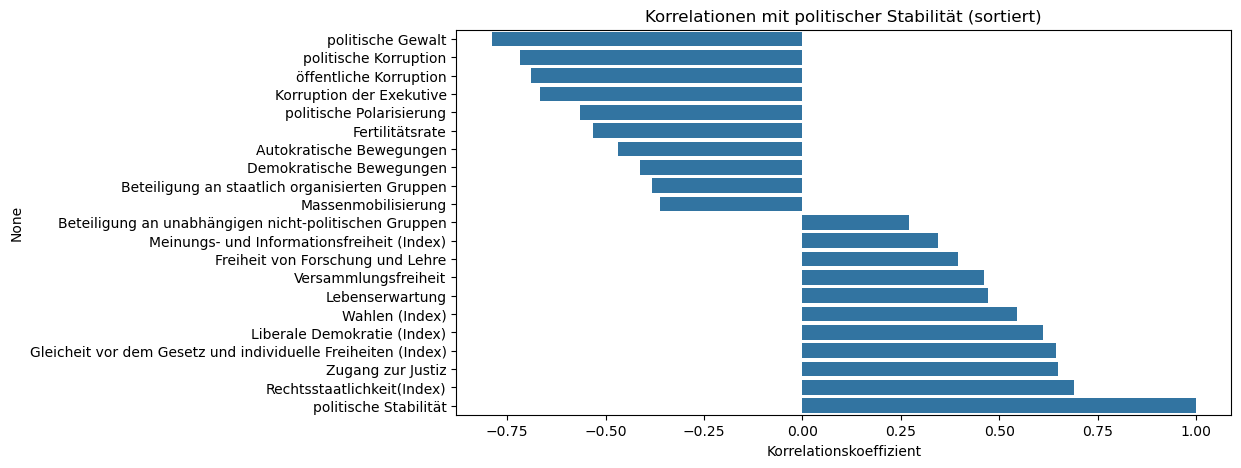

In [86]:
plt.figure(figsize=(10, 5))
sns.barplot(x=Korrelationen_sorted.values, y=Korrelationen_sorted.index) 
# y=Korrelationen_sorted.index --> Das sind die Variablennamen, x= Korrelationen_sorted.values --> 
#Werte(Korrelationskoeffizienten)
plt.xlabel('Korrelationskoeffizient')
plt.title('Korrelationen mit politischer Stabilität (sortiert)')
plt.show()

* Starker negativer Zusammenhang: Die Variablen politische Gewalt sowie die verschiedenen Formen von Korruption (politisch, öffentlich, Exekutive) zeigen einen deutlich negativen Zusammenhang mit der politischen Stabilität. Je stärker diese Merkmale ausgeprägt sind, desto niedriger ist in der Regel die politische Stabilität eines Landes. Diese Variablen haben somit einen besonders starken Einfluss auf instabile Länder.

* Starker positiver Zusammenhang: Ein klar positiver Zusammenhang besteht bei Variablen wie liberale Demokratie, Rechtsstaatlichkeit, Zugang zur Justiz, Gleichheit vor dem Gesetz sowie individuelle Freiheitsrechte. Hohe Ausprägungen in diesen Bereichen gehen typischerweise mit höherer politischer Stabilität einher und charakterisieren somit politisch stabile Länder.

* Wirtschaftliche Faktoren wie BIP, Exporte, Importe oder Inflation zeigen hingegen überraschend geringe Korrelationen mit der politischen Stabilität. Ihr Einfluss scheint im Vergleich zu demokratischen oder gewaltbezogenen Faktoren begrenzt zu sein.

* Ferner legt die Analyse nahe, welche Variablen besonders relevant für Clusteranalysen sein könnten: Nämlich diejenigen mit einer hohen Korrelation. 

## EDA Highlight 2

#### Gruppieren nach stark negativen Korrelationsvariablen
* ich möchte alle Länder mit hohen Werten in den Variablen der Korruption und in der Variable politische Gewalt etc.. in eine Gruppe überführen.
* danach möchte ich zur Veranschaulichung eine Verteilung erstellen. 
* Abschließend möchte ich wissen welche Länder enthalten sind, und wie häufig.

In [87]:
# Erstellen der Gruppe anhand ihrer quantile
gewalt_korrupte_länder = Data[
    (Data["politische Gewalt"] > Data["politische Gewalt"].quantile(0.66)) &
    (Data["politische Korruption"] > Data["politische Korruption"].quantile(0.66)) &
    (Data["öffentliche Korruption"] > Data["öffentliche Korruption"].quantile(0.66)) &
    (Data["Korruption der Exekutive"] > Data["Korruption der Exekutive"].quantile(0.66))
]

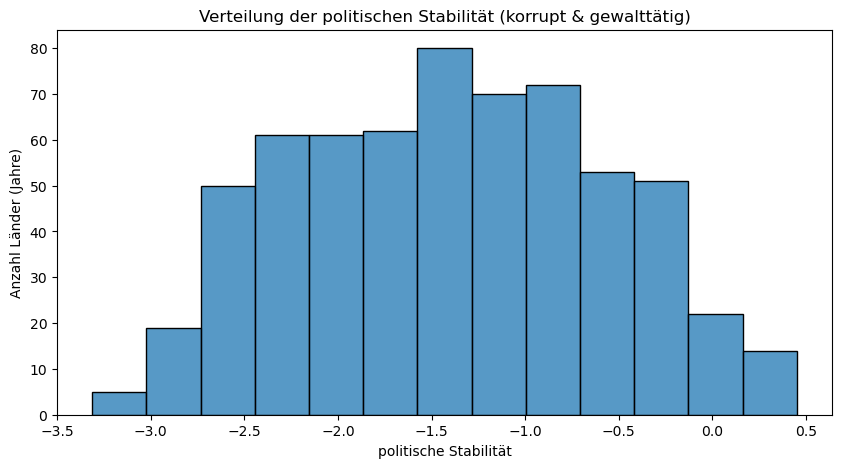

In [88]:
#Plotten
plt.figure(figsize=(10, 5))
sns.histplot(gewalt_korrupte_länder["politische Stabilität"])
plt.title('Verteilung der politischen Stabilität (korrupt & gewalttätig)')
plt.xlabel('politische Stabilität')
plt.ylabel('Anzahl Länder (Jahre)')
plt.show()

* Während der Durschnitt der politischen Stabilität ohne Filterung nach politischer Gewalt und Korruptionsarten noch bei 0 lag, liegt er nun bei -1.38926. Es ist also davon auszugehen, dass die ausgewählten Länder mit hoher politischer Gewalt und ausgeprägten Korruptionsformen deutlich instabiler sind als der globale Durchschnitt, was bestätigt, dass diese Variablen starke Prädiktoren für politische Instabilität darstellen.

## EDA Highlight 3

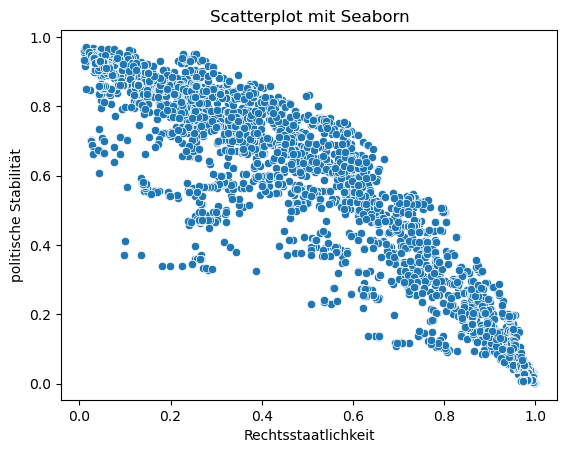

In [89]:
sns.scatterplot(data=Data, x="Rechtsstaatlichkeit(Index)", y='politische Korruption')

# Titel und Achsenbeschriftung
plt.title('Scatterplot mit Seaborn')
plt.xlabel('Rechtsstaatlichkeit')
plt.ylabel('politische Stabilität')

# Zeige das Diagramm
plt.show()

Der Plot zeigt, wie sich die Daten verhalten könnten, wenn alle Features in eine Clusteranalyse mit eingebunden sind.
Die Daten weisen gemäß der Korrelation zur politischen Stabilität auf ein zweidimensionales Spektrum zwischen liberal, rechtsstatlich und autoritär korrupt hin.

# Task 5 -- Dimensionality Reduction

<div class="alert alert-block alert-warning"> 
<b>PCA</b>: 
Conduct your analyses and transformations according to Task 5.
Call the transformed dataset "data_pca".

(Commented code + bullet points, add cells below)
</div>

In [90]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pca import pca

* Ich muss die Variable der politischen Stabilität aus dem DF für die PCA entfernen, weil sie nicht nicht Teil der erklärenden Variablen ist. 
* Ferner dürfen keine NaN Werte enthalten sein.

In [91]:
Data_ohne_pS = Data.drop(columns=['politische Stabilität'])
Data_ohne_pS = Data_ohne_pS.dropna()

* Land und Jahr kann als index genutzt werden

In [92]:
pca_vorbereitung = Data_ohne_pS.set_index(['Land', 'Jahr'])

* Standardisieren der numerischen Daten

In [93]:
# alle numerischen Spalten müssen so transformiert werden, dass sie im Mittelwert = 0 und in der Standardabweichung = 1 haben.
scaler = StandardScaler()
data_pca_v = scaler.fit_transform(pca_vorbereitung)

# Es wird ein neuer DF erstellt (aus den skalierten Werten). Aber der Index bleibt sowie die Spaltennamen.
data_pca_v = pd.DataFrame(data_pca_v, index=pca_vorbereitung.index, columns=pca_vorbereitung.columns)

data_pca_v.round(2)

Liberale Demokratie (Index)  Wahlen (Index)  \
Land    Jahr                                                
Mexico  1996                        -0.44           -0.06   
        1998                        -0.12            0.28   
        2000                         0.27            0.53   
        2002                         0.32            0.62   
        2003                         0.34            0.66   
...                                   ...             ...   
Hungary 2018                        -0.13           -0.15   
        2019                        -0.17           -0.20   
        2020                        -0.19           -0.21   
        2021                        -0.24           -0.27   
        2022                        -0.27           -0.27   

              Meinungs- und Informationsfreiheit (Index)  \
Land    Jahr                                               
Mexico  1996                                        0.06   
        1998                                        0.06   
        2000                                        0.37   
        2002                                        0.45   
        2003                                        0.45   
...                                                  ...   
Hungary 2018                                       -0.31   
        2019                                       -0.33   
        2020                                       -0.45   
        2021                                       -0.51   
        2022                                       -0.55   

              Gleicheit vor dem Gesetz und individuelle Freiheiten (Index)  \
Land    Jahr                                                                 
Mexico  1996                                              -0.32              
        1998                                              -0.32              
        2000                                              -0.31              
        2002                                              -0.27              
        2003                                              -0.27              
...                                                         ...              
Hungary 2018                                               0.82              
        2019                                               0.81              
        2020                                               0.75              
        2021                                               0.77              
        2022                                               0.78              

              Zugang zur Justiz  Rechtsstaatlichkeit(Index)  \
Land    Jahr                                                  
Mexico  1996              -0.93                       -0.17   
        1998              -0.93                       -0.12   
        2000              -0.93                        0.22   
        2002              -0.93                        0.25   
        2003              -0.93                        0.16   
...                         ...                         ...   
Hungary 2018               0.71                        0.44   
        2019               0.71                        0.41   
        2020               0.71                        0.32   
        2021               0.71                        0.28   
        2022               0.65                        0.13   

              öffentliche Korruption  politische Korruption  \
Land    Jahr                                                  
Mexico  1996                    0.05                   0.49   
        1998                   -0.16                   0.42   
        2000                   -0.37                   0.14   
        2002                   -0.44                   0.21   
        2003                    0.02                   0.32   
...                              ...                    ...   
Hungary 2018                   -0.92                  -0.13   
        2019                   -0.92 

* Die Tabelle zeigt die standardisierten Werte der Variablen. Dieser Schritt ist wichtig, weil er sicherstellt, dass alle Variablen denselben Einfluss auf den PCA-Prozess haben. Andernfalls könnte PCA durch Variablen mit größeren Zahlen dominiert werden, was das Ergebnis verzerren würde.

In [94]:
data_pca_v.cov().round(2)

,Liberale Demokratie (Index),Wahlen (Index),Meinungs- und Informationsfreiheit (Index),Gleicheit vor dem Gesetz und individuelle Freiheiten (Index),Zugang zur Justiz,Rechtsstaatlichkeit(Index),öffentliche Korruption,politische Korruption,Korruption der Exekutive,Fertilitätsrate,Lebenserwartung,politische Polarisierung,politische Gewalt,Versammlungsfreiheit,Massenmobilisierung,Autokratische Bewegungen,Demokratische Bewegungen,Beteiligung an staatlich organisierten Gruppen,Beteiligung an unabhängigen nicht-politischen Gruppen,Freiheit von Forschung und Lehre
Liberale Demokratie (Index),1.00,0.98,0.85,0.88,0.83,0.91,-0.81,-0.79,-0.81,-0.48,0.53,-0.45,-0.49,0.87,-0.02,-0.60,-0.09,-0.64,0.46,0.82
Wahlen (Index),0.98,1.00,0.90,0.88,0.79,0.85,-0.73,-0.70,-0.72,-0.43,0.48,-0.38,-0.42,0.91,0.04,-0.58,-0.01,-0.62,0.45,0.86
Meinungs- und Informationsfreiheit (Index),0.85,0.90,1.00,0.84,0.72,0.71,-0.54,-0.50,-0.55,-0.19,0.27,-0.29,-0.22,0.92,0.15,-0.53,0.18,-0.57,0.49,0.92
Gleicheit vor dem Gesetz und individuelle Freiheiten (Index),0.88,0.88,0.84,1.00,0.92,0.88,-0.75,-0.72,-0.74,-0.44,0.44,-0.43,-0.52,0.86,-0.04,-0.61,-0.00,-0.55,0.47,0.83
Zugang zur Justiz,0.83,0.79,0.72,0.92,1.00,0.88,-0.76,-0.76,-0.76,-0.44,0.44,-0.46,-0.54,0.73,-0.09,-0.56,-0.05,-0.50,0.47,0.71
Rechtsstaatlichkeit(Index),0.91,0.85,0.71,0.88,0.88,1.00,-0.93,-0.92,-0.92,-0.50,0.53,-0.50,-0.57,0.76,-0.15,-0.61,-0.19,-0.58,0.45,0.72
öffentliche Korruption,-0.81,-0.73,-0.54,-0.75,-0.76,-0.93,1.00,0.96,0.93,0.57,-0.61,0.46,0.58,-0.61,0.20,0.55,0.27,0.54,-0.39,-0.56
politische Korruption,-0.79,-0.70,-0.50,-0.72,-0.76,-0.92,0.96,1.00,0.95,0.54,-0.56,0.50,0.60,-0.57,0.23,0.55,0.32,0.52,-0.38,-0.53
Korruption der Exekutive,-0.81,-0.72,-0.55,-0.74,-0.76,-0.92,0.93,0.95,1.00,0.52,-0.56,0.49,0.57,-0.61,0.19,0.54,0.28,0.54,-0.39,-0.58
Fertilitätsrate,-0.48,-0.43,-0.19,-0.44,-0.44,-0.50,0.57,0.54,0.52,1.00,-0.81,0.25,0.54,-0.34,0.09,0.30,0.20,0.43,0.01,-0.24


* Zu sehen ist eine Kovarianzmatrix. Ein Wert von 1 bedeutet, dass die Werte identisch sind und damit gleichzeitig variieren. Also gleichzeitig steigen oder fallen. 
* Eine negative Kovarianz bedeutet, dass die eine Variable steigt, wenn die andere sinkt, und umgekehrt. 
* 0 bedeutet, dass keine lineare Beziehung zwischen den beiden Variablen besteht.

* Diese Infos sind wichtig für die PCA.
* Wenn zwei Variablen eine hohe Kovarianz haben, dann bedeutet dies, dass sie ähnliche Informationen liefern. Diese beiden Variablen könnten also zu einer einzigen Hauptkomponente zusammengefasst werden.
* Wenn zwei Variablen kaum korreliert sind (d.h., ihre Kovarianz ist nahe bei null), deutet dies darauf hin, dass sie unterschiedliche Informationen liefern. In diesem Fall kann PCA sie als getrennte Hauptkomponenten behandeln, da sie unterschiedliche Aspekte der Daten erklären.

# PCA anwenden

In [95]:
pca = PCA() # Es wird ein PCA-Objekt erstellt. Berechnet (Eigenvektoren) basierend auf der Kovarianzmatrix.
pca_t= pca.fit_transform(data_pca_v) # PCA wird auf die standardisierten Daten angewendet und transformiert diese. 
pca_t = pd.DataFrame(pca_t, index=pca_vorbereitung.index) # Erstellung eines neuen Dfs mit den PCA-Ergebnissen. Die Indizes von pca_vorbereitung werden übernomen. 
pca_t.round(2)

0     1     2     3     4     5     6     7     8     9   \
Land    Jahr                                                               
Mexico  1996 -0.84  1.26 -1.02  0.08 -0.94 -0.07 -1.11 -0.33  0.23 -0.14   
        1998 -0.30  1.25 -0.96 -0.05 -1.07 -0.04 -1.04 -0.06 -0.17 -0.06   
        2000  0.62  1.57 -1.00 -0.23 -0.69 -0.07 -1.18  0.57 -0.93  0.20   
        2002  0.91  0.92 -0.70 -0.58 -0.53  0.02 -1.17  0.15 -0.96 -0.07   
        2003  0.65  1.05 -0.77 -0.77 -0.84 -0.14 -1.07  0.14 -1.01  0.14   
...            ...   ...   ...   ...   ...   ...   ...   ...   ...   ...   
Hungary 2018 -0.00  0.73 -3.00  0.09 -0.67 -1.34  0.40 -0.38  1.61 -0.99   
        2019  0.19  0.03 -2.44 -0.33 -0.22 -1.15  0.82 -0.43  1.30 -0.74   
        2020  0.28 -1.16 -1.51 -0.77  0.28 -0.96  1.51 -0.72  1.02 -0.42   
        2021  0.06 -1.39 -1.39 -0.62  0.32 -1.00  1.33 -1.02  1.41 -0.31   
        2022 -0.46  0.77 -3.01 -0.01 -0.70 -1.37  0.69  0.03  1.25 -0.89   

                10    11    12    13    14    15    16    17    18    19  
Land    Jahr                                                              
Mexico  1996  1.43 -0.69  0.63 -0.12  0.24 -0.01  0.08  0.11  0.26 -0.19  
        1998  1.52 -0.66  0.25 -0.12  0.32 -0.14  0.12  0.00  0.32 -0.18  
        2000  1.23 -0.46  0.03 -0.11  0.04 -0.13  0.12  0.05  0.38 -0.14  
        2002  0.88 -0.29  0.12 -0.02  0.08  0.02  0.09  0.04  0.47 -0.18  
        2003  0.91 -0.26  0.06 -0.23 -0.16 -0.13  0.17  0.09  0.34 -0.17  
...            ...   ...   ...   ...   ...   ...   ...   ...   ...   ...  
Hungary 2018  0.42  0.12 -0.13  1.30  0.61  0.12 -0.09  0.22  0.11  0.00  
        2019  0.16  0.35 -0.13  1.36  0.54  0.14 -0.10  0.18  0.12  0.02  
        2020 -0.07  0.51 -0.18  1.17  0.67  0.17 -0.14  0.09  0.13  0.03  
        2021 -0.06  0.29 -0.15  1.18  0.67  0.18 -0.09  0.08  0.07  0.05  
        2022  0.26  0.28 -0.27  1.44  0.61  0.08 -0.01  0.03  0.08  0.05  

[4013 rows x 20 columns]

[scatterd] >INFO> Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
[scatterd] >INFO> Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


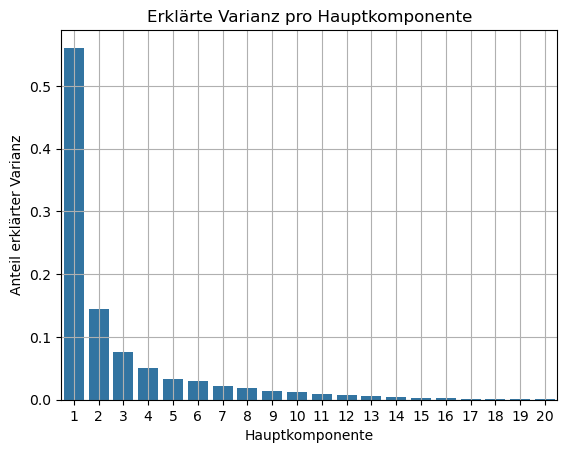

In [96]:
explained_variance = pca.explained_variance_ratio_
# pca.explained_variance_ratio_ ist ein Array mit Werten zwischen 0 und 1.
# Jeder Wert steht für den Anteil der Gesamtvarianz, den eine bestimmte Hauptkomponente erklärt.
sns.barplot(x=range(1, len(explained_variance)+1), y=explained_variance)
# (x=range(1, len(explained_variance)+1) --> die X-Achse wird mit 1, 2, 3, … (statt mit 0) beschriftet wird.
plt.title("Erklärte Varianz pro Hauptkomponente")
plt.xlabel("Hauptkomponente")
plt.ylabel("Anteil erklärter Varianz")
plt.grid(True)
plt.show()

* Diese Werte stellen den Anteil der erklärten Varianz pro Hauptkomponente (PC) dar. Die Summe aller Werte ergibt 1 bzw. 100 % und zeigt, wie viel Information (Varianz) jede Komponente aus dem ursprünglichen Datensatz erhält.

* Typischerweise wählt man so viele Komponenten, dass 90% der Varianz erklärt sind. In meinem Fall wähle ich die ersten 7 Komponenten (91,7%). 
* Die Tatsache, dass die erste Komponente (56%) so dominant ist zeigt, dass viele Variabeln korrelieren. Das liegt wahrscheinlich an den  Korruptionsindikatoren, die gemeinsam varieren. 

# Erstellen des Dataframes " data_pca mit den ersten 7 Komponenten

In [146]:
from pca import pca
pca = pca(n_components=7)

# Fit transform
results = pca.fit_transform(data_pca_v)

#erstellen des Dfs
data_pca = results['PC']

[pca] >Extracting column labels from dataframe.
[pca] >Extracting row labels from dataframe.
[pca] >The PCA reduction is performed on the [20] columns of the input dataframe.
[pca] >Fit using PCA.
[pca] >Compute loadings and PCs.
[pca] >Compute explained variance.
[pca] >Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[7]
[pca] >Multiple test correction applied for Hotelling T2 test: [fdr_bh]
[pca] >Outlier detection using SPE/DmodX with n_std=[3]


# Problem: Woher weiß ich was sich hinter den PC1,PC2 etc.. verbirgt?
* Antwort: Loadings. PC1 etc.. sind Eigenvektoren. Diese bestehen aus den Loadings aller Variablen. Die Loadings wiederum sind Gewichte, mit denen jede ursprüngliche Variable zur jeweiligen Hauptkomponente (PC) beiträgt. Sie zeigen, wie stark und in welche Richtung eine Variable den Eigenvektor beeinflusst.

In [147]:
pca.results['loadings'].round(3) 

,Liberale Demokratie (Index),Wahlen (Index),Meinungs- und Informationsfreiheit (Index),Gleicheit vor dem Gesetz und individuelle Freiheiten (Index),Zugang zur Justiz,Rechtsstaatlichkeit(Index),öffentliche Korruption,politische Korruption,Korruption der Exekutive,Fertilitätsrate,Lebenserwartung,politische Polarisierung,politische Gewalt,Versammlungsfreiheit,Massenmobilisierung,Autokratische Bewegungen,Demokratische Bewegungen,Beteiligung an staatlich organisierten Gruppen,Beteiligung an unabhängigen nicht-politischen Gruppen,Freiheit von Forschung und Lehre
PC1,0.284,0.273,0.238,0.275,0.265,0.286,-0.264,-0.260,-0.263,-0.166,0.177,-0.165,-0.184,0.254,-0.049,-0.209,-0.057,-0.204,0.141,0.241
PC2,0.095,0.159,0.294,0.115,0.052,-0.016,0.108,0.139,0.101,0.181,-0.140,0.260,0.325,0.208,0.454,0.094,0.494,0.002,0.170,0.253
PC3,-0.010,0.002,0.148,0.047,0.033,-0.020,0.129,0.089,0.087,0.526,-0.504,-0.272,0.003,0.081,-0.354,-0.266,-0.194,0.073,0.265,0.151
PC4,-0.010,-0.089,-0.148,0.015,0.153,0.166,-0.238,-0.279,-0.251,0.132,-0.069,-0.059,0.006,-0.189,0.127,0.333,0.069,0.504,0.490,-0.186
PC5,-0.008,-0.047,-0.069,-0.179,-0.147,0.102,-0.245,-0.241,-0.229,0.165,-0.023,0.474,0.499,-0.148,-0.151,-0.224,-0.135,-0.357,0.122,-0.041
PC6,-0.048,-0.035,-0.006,-0.102,-0.128,-0.183,0.143,0.199,0.190,-0.210,0.443,-0.180,0.120,0.012,-0.084,-0.109,-0.001,-0.145,0.716,-0.012
PC7,-0.124,-0.083,-0.073,0.239,0.258,-0.015,0.033,0.071,0.145,-0.268,-0.065,0.565,-0.201,-0.020,-0.268,-0.402,0.151,0.339,0.113,0.017


* Positive Loadings (z. B. +0.286 für „Rechtsstaatlichkeit“) --> Diese Variablen sind positiv mit PC1 korreliert. Je höher diese Werte im Datensatz, desto stärker wird die Beobachtung entlang der PC1-Achse in positive Richtung verschoben.

* Negative Loadings (z. B. –0.264 für „öffentliche Korruption“) --> Diese Variablen sind negativ mit PC1 korreliert. Je höher der Wert bei diesen Variablen, desto stärker wird die Beobachtung entlang der PC1-Achse in negative Richtung verschoben.

* Ich habe mir die Loadings für alle PC- Komponenten ausgeben lassen und zusammengefasst:

PC1: Ein hoher PC1-Wert zeigt starke Institutionen, Rechtsstaatlichkeit und geringe Korruption; ein niedriger Wert das Gegenteil.

PC2: Ein hoher PC2-Wert deutet auf Staaten hin, die von aktiven demokratischen Bewegungen, einer freien Meinungsbildung und einer breiten politischen Teilnahme geprägt sind. Ein negativer Wert bedeutet das Gegenteil.

PC3: Ein niedriger PC3-Wert deutet auf Länder mit hoher Fertilität, niedriger Lebenserwartung und geringer gesellschaftlicher Mobilisierung hin, was oft mit weniger entwickelten oder politisch instabileren Staaten in Verbindung gebracht wird. Ein positiver Wert bedeutet das Gegenteil.

PC4: Ein hoher Wert in PC4 bedeutet, in diesen Ländern eine stärkere Teilnahme an staatlich organisierten Gruppen sowie zivilgesellschaftlichen Aktivitäten zufinden ist, die mit weniger Korruption einhergeht.

PC5: Ein hoher PC5-Wert steht für Länder, in denen politische Gewalt und Polarisierung besonders ausgeprägt sind. Diese Länder befinden sich vermutlich in einem Zustand tiefer politischer Fragmentierung oder sogar in einer Krise. Ein niedriger PC5-Wert zeigt Länder mit stärkerer Einbindung der Bevölkerung in organisierte Strukturen, weniger politischer Gewalt und geringerer Polarisierung.

PC6: Ein hoher PC6-Wert deutet auf Länder mit starkem Engagement in nicht-politischen zivilgesellschaftlichen Bereichen hin, begleitet von relativ hoher Lebenserwartung und möglicherweise schwächer ausgeprägter politischer Beteiligung. Es handelt sich um Gesellschaften mit sozialer Stabilität, aber ohne zwingend starke oder demokratisch legitimierte politische Institutionen.

PC7: Ein hoher PC7-Wert zeigt Staaten mit starker ideologischer Polarisierung innerhalb der Gesellschaft, oft trotz oder gerade wegen gut funktionierender Institutionen. Dies könnte auf „gespaltene Demokratien“ hinweisen – etwa reife Demokratien mit zunehmendem Populismus, Identitätspolitik oder Lagerbildung. Ein niedriger PC7-Wert hingegen kennzeichnet Länder mit stärkerer autoritärer Kontrolle, weniger gesellschaftlicher Spaltung, aber auch geringerer öffentlicher Beteiligung und eher technokratischer oder repressiver Stabilität.

# Task 6 -- Clustering

<div class="alert alert-block alert-warning"> 
<b>Choice of Algorithm</b>: 
Given the situation in the pitch and the results from the above analyses. Which algorithm (chosen from those discussed in the lectures) would YOU choose for the clustering? Explain!
    
(Choice + 1-3 bullet points in the cell below)
</div>

My Choice: ...

* Ich würde ein soft Clustering (EM (Gaussian Mixture Model - (Vorlesung 11))) wählen. (Auch wenn wir dieses Clustering nicht in diesem Portfolio nutzen sollen) 
Die Beobachtungen des Vdem-Datensatzes lassen sich nicht eindeutig in ein Kugelförmiges Cluster überführen und lassen sich mit bloßem Auge auch nur sehr schwer einem Cluster zuordnen. Der Hintergrund könnte sein, dass sich viele Länder in einer Transformation befinden (Demokratie --> Autokratie).
* Aus diesem Grund können Merkmale je Land stark variieren und sind volatil, weshalb ein "weiche Zuordnung" angebracht ist.
* Außerdem weisen viele Variablen auf einen Zusammenhang mit der politischen Stabilität hin. Weshalb ich eher elliptische Cluster erwarte. 
* Zudem weisen die Länder wahrscheinlich Merkmale mehrerer Typen auf. Wenn ein Land politisch korrupt ist, dann ist  wahrscheinlich auch die executive korrupt, sowie die Öffentlichkeit. --> GMM erlaubt wahrscheinlichkeiten.

<div class="alert alert-block alert-danger"> 
<b>Requirements</b>: 
In the following and for the remainder of the final phase of the exam (indenpendent of what your choice above suggests), use 

* a clustering algorithm $A$ chosen from the family: __k-means/k-means++__
* the evaluation metric $E_1$: __Silhouette Score__
* the evaluation metric $E_2$: __Davies-Bouldin Index__.
</div>

In [99]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

## Comprehensive clustering analysis
<div class="alert alert-block alert-warning"> 
<b>Clustering</b>: 
On both datasets, data and data_pca, under their respective headlines below, conduct comprehensive clustering analyses with algorithm $A$, using the available methodology from the module and specifically $E_1$ and $E_2$. Conduct ALL necessary steps to create the most helpful and meaningful clustering per dataset and discuss its quality. Use appropriate diagrams to demonstrate the results. 

(Commented code + bullet points, add cells)
</div>

# Clustering Analysis of plain data

### K-Means

In [100]:
# Die Spalten Land und Jahr sollten als index genutzt werden (bei allen Clusterings). Data_ohne_pS enthält die Zielvariable der politischen Stabilität nicht, ist aber ansonsten mit Data identisch.
# Diese sollte keinen Einfluss auf das Clustern nehmen. Das gilt für alle Clusterings.
Data_plain = Data_ohne_pS.set_index(['Land', 'Jahr'])

In [101]:
# da ich mehrere features mit unterschiedlich hohen Metriken habe, muss ich alle Werte standardiesieren. - Wie beim PCA
# --> hohe Werte würden sonst die Clusterbildung dominieren. 
scaler = StandardScaler()
X = scaler.fit_transform(Data_plain)
# fit() berechnet Mittelwert und Standardabweichung für jede Spalte, transform() skaliert die Werte entsprechend.

In [102]:
# ich möchte mehrere K auspropbieren und das beste Cluster auswählen. 
# Erstellen leerer Listen um die Ergebnisse zu speichern. 
silhouette_scores = []
db_scores = []
k_values = range(2, 11)  # k = 2 bis 10

# Schleife für verschiedene k
for k in k_values:
    kmeans_plain = KMeans(
        n_clusters=k,
        init='k-means++',  # es ändert sich nichts an E1 und E2, wenn ich random eingebe. 
        n_init= 20,   # es ändert sich nichts E1 und E2, wenn man n_init höher oder niedriger einstellt. 
        max_iter= 300,#  wenn max_iter z.B. = 1 bzw. sehr klein ist, verschlechtert sich E1 und E2
        tol= 0.0001, # Je höher tol, desto schlechter E1 und E2. Merklich aber erst bei ca. 100
        random_state= 42 
    )
    
    cluster_assignments1 = kmeans_plain.fit_predict(X)

    # speichert den berechneten silhouette_score und davies_bouldin_score in den Listen für jedes K.
    sil = silhouette_score(X, cluster_assignments1)
    db = davies_bouldin_score(X, cluster_assignments1)
    
    silhouette_scores.append(sil)
    db_scores.append(db)

In [103]:
print(silhouette_scores)
print(db_scores)

[0.3401012819173013, 0.269487140695397, 0.2512390023125907, 0.23089466126925112, 0.2059969638585119, 0.20712546940437557, 0.18686338746973769, 0.1893266681695665, 0.18952802359443932]
[1.0875744907757732, 1.4777907714952858, 1.4761416070153701, 1.6378165218012293, 1.6818959984514337, 1.6928368807895435, 1.6460952550261567, 1.6715693199079082, 1.648255619166487]


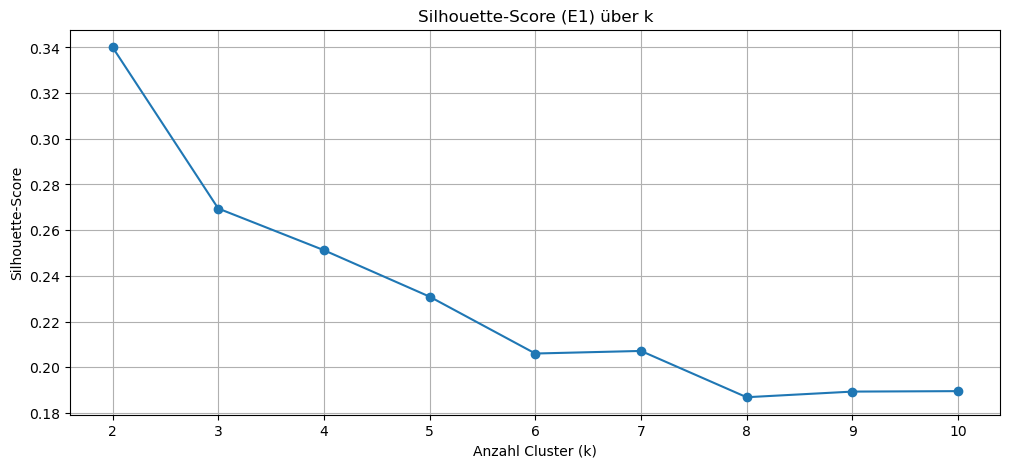

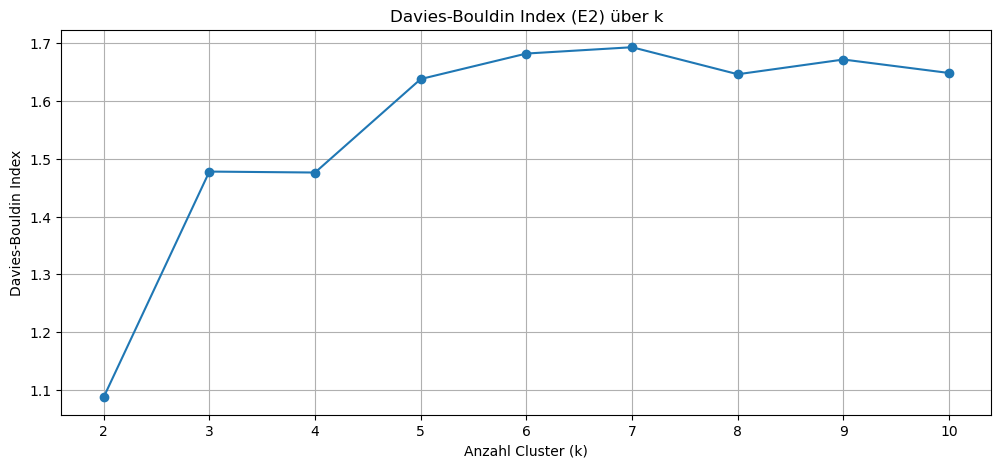

In [104]:
# Plot Silhouette-Score
plt.figure(figsize=(12, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette-Score (E1) über k")
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Silhouette-Score")
plt.grid(True)
plt.show()

# Plot Davies-Bouldin-Index
plt.figure(figsize=(12, 5))
plt.plot(k_values, db_scores, marker="o")
plt.title("Davies-Bouldin Index (E2) über k")
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Davies-Bouldin Index")
plt.grid(True)
plt.show()

#### Interpretation und Schlussfolgerungen bezüglich der Clusterqualität 
 
 * Ich habe veschieden viele Cluster (von 2 - 10) ausprobiert: Die Einstellung "2 Cluster" liefert die besten Ergebnisse. Dies gilt sowohl für den Silhouette-Scores als auch für den Davies-Bouldin Index. 

* Ein Davies-Bouldin Index von 1.0876 deutet auf ein mäßige bis Gute Clusterqualität hin. Je kleiner der Wert, desto geringer ist die Streuung innerhalb der Cluster. 

* Der Silhouette-Score misst die Kohäsion (Wie nah sind Punkte an anderen im gleichen Cluster?) und die Seperation (Wie weit sind sie von Punkten im nächsten Cluster entfernt?). Je höher der Wert, desto besser.  In diesem Kontext bedeutet ein Wert von 0.3401, dass eine Clusterstruktur vorhanden ist. Diese ist jedoch nicht Ideal, weshalb es überlappende bzw. unscharfe Grenzen zwischen den Clustern gibt. 

* Die Tatsache, dass nur 2 Cluster die besten Ergebnisse liefern, scheint daran zu liegen, dass sich die Daten Entlang eines eines zweidimensionalen Spektrums am besten Gruppieren lassen. Es handelt sich um ein Spektrum, welches Länder vermutlich von liberal demokratisch hin zu autoritär korrupt sortiert.

* Neben der Clusteranzahl beeinflussen Parameter wie init, n_init, max_iter und tol das KMeans-Ergebnis. init bestimmt die Startmethode der Zentren, „k-means++“ ist meist besser als zufällig. Dies ändert hier aber nix. n_init legt fest, wie oft mit verschiedenen Startpunkten neu gestartet wird, was die Ergebnisqualität verbessert.Macht hier aber auch keinen Unterschied. max_iter begrenzt die maximale Anzahl an Iterationen: zu klein kann zu ungenauen Clustern führen. tol definiert die Abbruchschwelle für die Konvergenz: ein zu hoher Wert kann die Qualität verschlechtern, ein zu niedriger verlängert die Laufzeit. 

* Vorzüge Kmeans:

K-means ist gut bei „runden“ Clustern. Wenn sich Cluster wirklich als kugelförmige Gruppen im Raum verteilen, liefert K‑means sehr präzise Ergebnisse.
Bei länglichen Clustern, wie es hier zu erwarten ist, könnten jedoch verzerrte Ergebnisse entstehen. Der DB und der Silhouette-Score wiesen hier immerhin 
auf eine insgesammt mittlere bis mäßige Qualität hin. Die Cluster sind daher wahrscheinlich nicht so richtig kugelförmig.

Ferner wird jeder Punkt eindeutig einem Cluster zugewiesen, was ein Vorteil ist, da keine Rauschpunkte gibt. 

Weiterhin werden die Zenter so gewählt, dass die Summe der quadrierten Abstände innerhalb jedes Clusters minimal wird. Dadurch tendieren die Cluster aber  auch dazu, etwa gleich groß (in Datenpunkten) zu sein, sofern die Verteilung der Punkte halbwegs homogen ist. --> hier sind die Cluster nicht wirklich gleich groß, weshalb die Verteilung wohl auch nicht so wirklich homogen ist. 

# Clustering Analysis of PCA transformed data

### K-means

In [105]:
silhouette_scores = []
db_scores = []
k_values = range(2, 11)  # k von 2 bis 10

for k in k_values:
    kmeans_pca = KMeans(
        n_clusters=k,           # Es gilt das Gleiche wie oben. 
        init='k-means++',       # 'random' verändert die Scores kaum. 
        n_init=20,              # Mehrfache Initialisierungen für stabilere Ergebnisse
        max_iter=300,           # max_iter zu klein = schlechtere Scores
        tol=0.0001,             # toleranz zu hoch = schlechtere Scores
        random_state=42       
    )
    
    cluster_assignments2 = kmeans_pca.fit_predict(data_pca)  # Clustern auf PCA-Daten
    
    sil = silhouette_score(data_pca, cluster_assignments2)   # Silhouette-Score berechnen
    db = davies_bouldin_score(data_pca, cluster_assignments2)  # Davies-Bouldin-Index berechnen
    
    silhouette_scores.append(sil)
    db_scores.append(db)

In [106]:
print(silhouette_scores)
print(db_scores)

[0.3703159581294548, 0.3004575721806981, 0.28500014160438536, 0.26203551904203265, 0.2417979483626299, 0.24148950521925042, 0.2231856441085952, 0.22574039232596, 0.22597807957036006]
[1.001285823717011, 1.3342656293334623, 1.3141169450132444, 1.4422948802507614, 1.4656635004351124, 1.506949655896556, 1.453492769127903, 1.479441694381538, 1.4330915670610578]


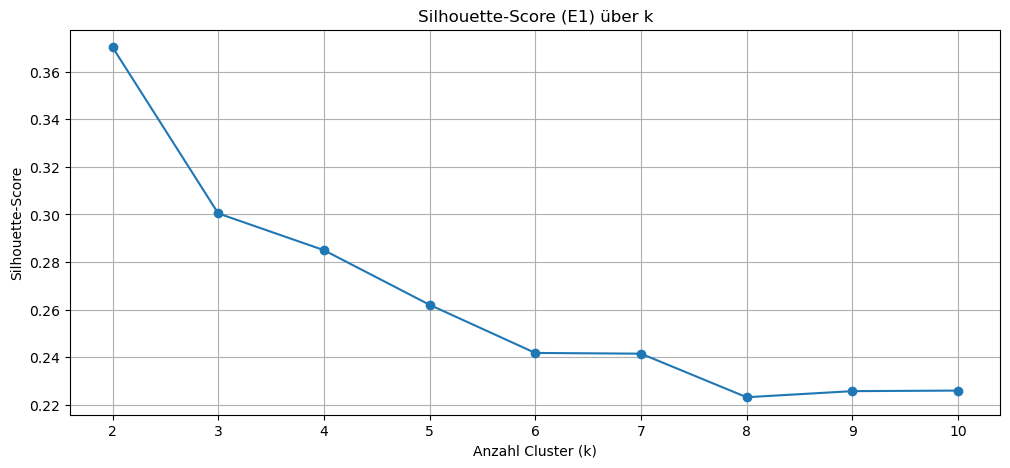

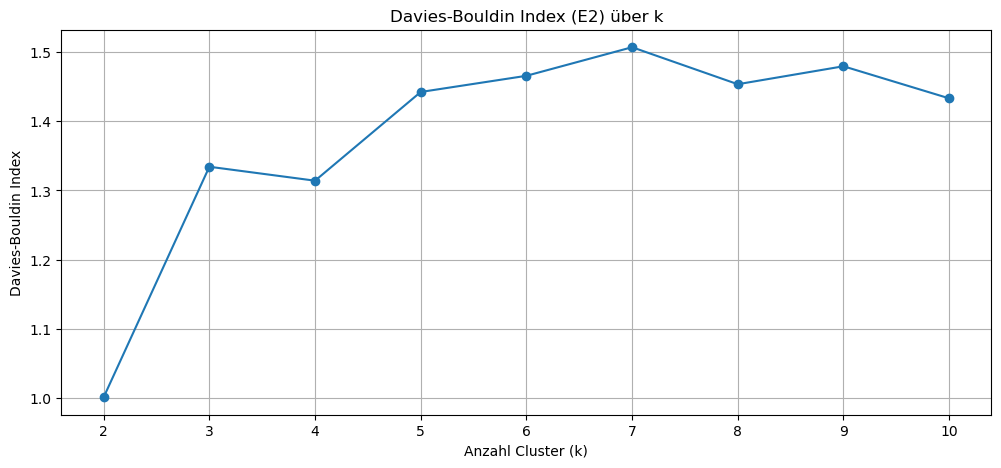

In [107]:
# Plot Silhouette-Score
plt.figure(figsize=(12, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette-Score (E1) über k")
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Silhouette-Score")
plt.grid(True)
plt.show()

# Plot Davies-Bouldin-Index
plt.figure(figsize=(12, 5))
plt.plot(k_values, db_scores, marker="o")
plt.title("Davies-Bouldin Index (E2) über k")
plt.xlabel("Anzahl Cluster (k)")
plt.ylabel("Davies-Bouldin Index")
plt.grid(True)
plt.show()

* Ebenso wie beim Clustering mit den plain Daten liefert die Einstellung "2 Cluster" die besten Ergebnisse.
* Sowohl E1 als auch E2 haben sich jedoch leicht verbessert gegenüber dem Cluster ohne PCA. (E1: 0.37883411628623176, E2:1.001)
* PCA hilft dem algorithmus also tatsächlich beim CLustern, indem es  die Daten auf die relevantesten Hauptkomponenten, die den Großteil der Varianz erklären, reduziert. 

# Task 7 -- Clustering Comparison

<div class="alert alert-block alert-warning"> 
<b>Comparison</b>: 
Compare both clustering from the previous task as described in Task 7.

(Commented code + bullet points, add cells below)
</div>

* Die Anzahl der Cluster ist sowohl beim Clustern mit PCA als auch beim Clustern ohne PCA identisch. n = 2 (bezüglich Kmeans

* Rauschpunkte: K-Means zwingt jede Datenpunktzuordnung zu einem Cluster. Jeder Punkt wird dem nächstgelegenen Clusterzentrum (nach euklidischer Distanz) zugewiesen. Daher gibt es keine Rauschpunkte.

* Silhouette-Score (𝐸1) (Je höher desto besser): Ohne PCA: 0.3401012819173013, mit PCA: 0.3703159581294548 
--> Auch wenn K-Means kein Rauschen erkennt, kann es von „störenden Informationen“ in den Daten beeinflusst werden. Manche Variablen tragen wenig zur Clusterstruktur bei. Diese Variablen wirken dann wie Rauschen im Feature-Sinn und fügen unnötige Komplexität hinzu und verzerren dadurch die Clusterzentren. PCA hilft dabei, diese störenden Effekte zu reduzieren, indem die Dimensionen reduziert werden. 

* Davies-Bouldin Index (𝐸2) (je niedriger desto besser): Ohne PCA: 1.0875744907757732 , mit PCA :1.001285823717011
--> Mit PCA ist der Wert niedriger. Die Cluster sind also kompakter (Distanzen innerhalb der Cluster kleiner) und/oder besser voneinander getrennt (größere Abstände zwischen Clustern). ICh denke, dass der gleiche Grund dafür verantwortlich ist. 

Insgesamt ist der Unterschied bei E1 und E2 nicht riesig, aber spürbar. PCA hilft, die Clusterstruktur zu verbessern, auch wenn beide Clusteralgorithmen ergeben, dass es keine sehr klar trennbaren Cluster gibt. 

### Dateninstanzen

* ich möchte einen Crosstab erstellen. Dieser soll zeigen ob die gleichen Instanzen in den gleichen Clustern gelandet sind. (Instanzvergleich zwischen PCA-Clustern und ohne-PCA-Clustern)

In [110]:
# Damit ich die Clusterings nach ihren Instanzverteilungen vergleichen kann, muss ich nochmal beide Clusterings für k = 2 durchführen. 
# Ansonsten würde k = 10 aufgrund der Schleife genutzt werden. 

# Clustering ohne PCA (k=2)
kmeans_plain = KMeans(n_clusters=2, 
        init='k-means++',      
        n_init=20,              
        max_iter=300,            
        tol=0.0001,            
        random_state=42 )
cluster_assignments1 = kmeans_plain.fit_predict(X)

# Clustering mit PCA (k=2)
kmeans_pca = KMeans(n_clusters=2, 
        init='k-means++',      
        n_init=20,              
        max_iter=300,            
        tol=0.0001,            
        random_state=42)
cluster_assignments2 = kmeans_pca.fit_predict(data_pca)

# erstellen eines DF für den Vergleich
df_clusters = pd.DataFrame({
    'Cluster_ohne_PCA': cluster_assignments1,
    'Cluster_PCA': cluster_assignments2
})
# erstellen eines crosstaps.
# Da K-Means keine echte „Cluster-Bedeutung“ kennt, kann Cluster 0 genauso gut Cluster 1 sein.
# Das ist bei mir passiert. .map({0: 1, 1: 0}) sorgt dafür, dass bei dem Cluster ohne PCA, Cluster 0 zu Cluster 1 wird und umgekehrt. 
cluster_vergleich = pd.crosstab(df_clusters["Cluster_ohne_PCA"].map({0: 1, 1: 0}), df_clusters["Cluster_PCA"])
print(cluster_vergleich)

Cluster_PCA          0     1
Cluster_ohne_PCA            
0                 1590     0
1                    3  2420


* 1590 Instanzen sind in Cluster 0 bei beiden Clustern (ohne und mit PCA).

* 2420 Instanzen sind in Cluster 1 bei beiden Clustern.

* Nur 3 Instanzen  wurden unterschiedlich zugeordnet. Das sind unter 0.5% der Daten.

-->Die Cluster ohne PCA und die Cluster mit PCA sind fast identisch in ihrer Zuordnung der Dateninstanzen. Die Cluster-Ergebnisse sind also vergleichbar. Das PCA-Clustering hat kaum etwas verändert. Vielmehr hat es nur die Struktur etwas verbessert und unterstützt.

# Task 8 -- Conclusions and Future Work

<div class="alert alert-block alert-warning"> 
<b>Subtasks</b>: 
For each subtask, create a fitting headline and add additional code and markdown cells below to conduct the respective task.
    
(Commented code + bullet points, add cells below)
</div>


# Nr 1) wahl des Clusters

* Ich wähle das Cluster-Ergebnis mit PCA (also das Clustering, das auf den Hauptkomponenten basiert) und Algorithmus A (Kmeans++) als Endergebnis aus.

* Begründung:

Bessere Clusterbewertung: Der Silhouette-Score des PCA-basierten Clusters ist mit 0.3703 höher als der des Clusters ohne PCA (0.3401). Der Davies-Bouldin Index ist bei der PCA-Variante mit 1.0013 niedriger als ohne PCA (1.0876). 

Ebenso sind die Ergebnisse dieses Algorithmus auch besser als die Ergebnisse von den Algotithmusfamilien b)(DBSCAN) und c) (HAC).
Bei DBSCAN, habe ich zudem nur sehr kleine CLuster erhalten und konnte den Ketteneffekt nicht loswerden. 
HAC lieferte ein Ergebnis, welches dem von Kmeans nahe kam. Das Dendogramm sorgte zudem für einen guten Einblick in die hierarchische Clusterstruktur. Dennoch fiel der Silhouette-Score und der Davies-Bouldin Index etwas schlechter aus. 

Dimensionalitätsreduktion: PCA reduziert die Dimensionen quasi auf die wichtigsten Komponenten, wodurch  die irrelevante Variabilität minimiert wird. Dadurch kann der Clustering-Algorithmus klarere Cluster erkennen.

# Nr 2) Diskussion der Clustermerkmale. 

* Da ich nun schon häufiger auf die Merkmale zur Clusterqualität eingegangen bin gehe ich hier davon aus, dass es in dieser Aufgabe um die Interpretation und den Vergleich der Merkmale bezüglich der Variablen der Cluster geht.
* Ferner habe ich die Mittelwerte aller Algotithmen ausversehen schon in der Draft Stage unter Aufgabe 6 dargestellt. (Nicht genau gelesen). Das werde ich hier einfach wiederholen.

* (Eine Interpretation der Merkmale in den Clustern ist noch
nicht notwendig, dies folgt später in Aufgabe 8) --> Ich hoffe, dass ich diese Anweisung richtig verstehe)

# Mittelwerte der Features je Cluster vergleichen:

# plain data:

Kmeans ohne PCA:

In [111]:
# hinzufügen der Zielvariable. Die Indexe müssen dafür gleich sein!
# Ich benötige die politische Stabilität aus Data.
Data.set_index(["Land", "Jahr"], inplace=True)

In [112]:
# Ich benötige die standardisierten Daten als DF. 
X_kmean = pd.DataFrame(X, columns=Data_plain.columns, index=Data_plain.index)

In [113]:
# Diesem Df möchte ich die eine Clusterzuordnung hinzufügen. 
X_kmean['Cluster'] = cluster_assignments1

In [114]:
# Analyse der Mittelwerte je feature + Vergleich der Zielvariable.
cluster_means = X_kmean.groupby('Cluster').mean()
cluster_means

,Liberale Demokratie (Index),Wahlen (Index),Meinungs- und Informationsfreiheit (Index),Gleicheit vor dem Gesetz und individuelle Freiheiten (Index),Zugang zur Justiz,Rechtsstaatlichkeit(Index),öffentliche Korruption,politische Korruption,Korruption der Exekutive,Fertilitätsrate,Lebenserwartung,politische Polarisierung,politische Gewalt,Versammlungsfreiheit,Massenmobilisierung,Autokratische Bewegungen,Demokratische Bewegungen,Beteiligung an staatlich organisierten Gruppen,Beteiligung an unabhängigen nicht-politischen Gruppen,Freiheit von Forschung und Lehre
Cluster,,,,,,,,,,,,,,,,,,,,
0,-0.685872,-0.650398,-0.513057,-0.593659,-0.580826,-0.677324,0.647614,0.645919,0.640578,0.412018,-0.430199,0.348993,0.462197,-0.556979,0.127007,0.444596,0.18597,0.456018,-0.277375,-0.523195
1,1.045200,0.991141,0.781848,0.904676,0.885120,1.032173,-0.986899,-0.984315,-0.976177,-0.627874,0.655581,-0.531830,-0.704342,0.848780,-0.193546,-0.677520,-0.28340,-0.694926,0.422691,0.797296


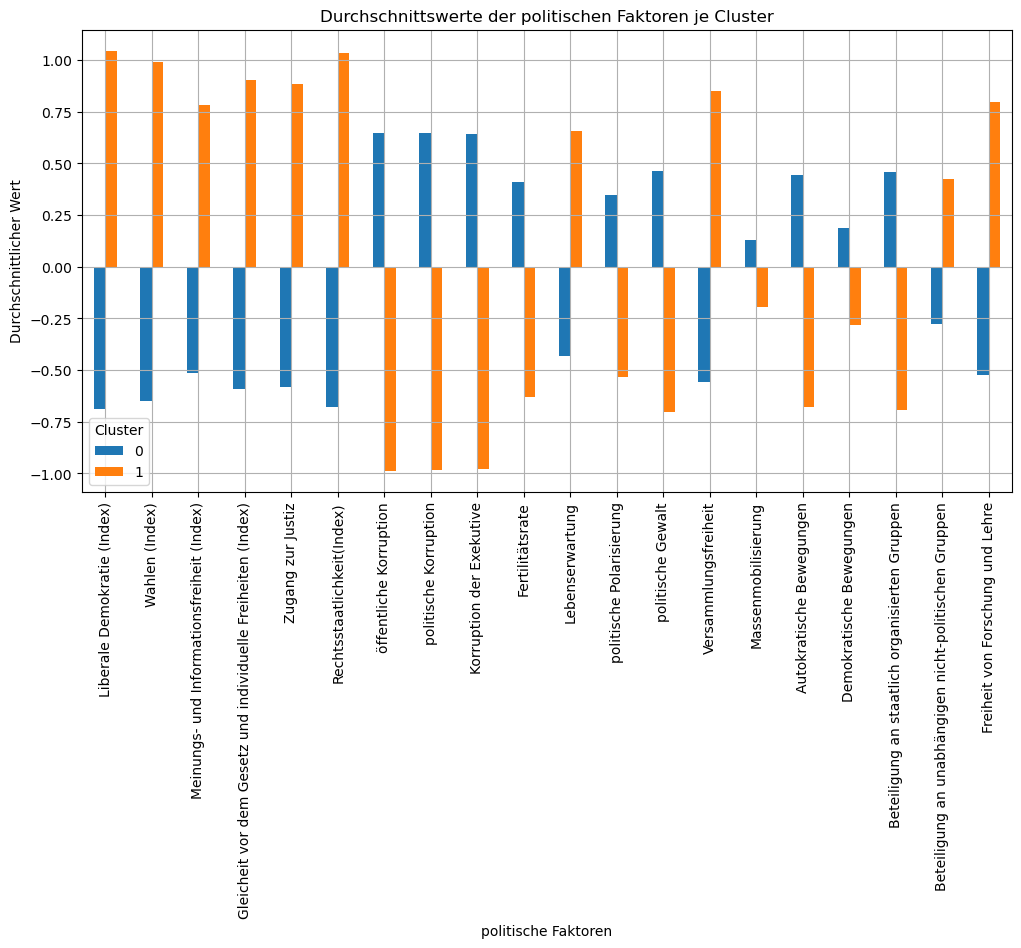

In [116]:
# Transponieren für bessere Darstellung im Barplot
cluster_mean1 = cluster_means.T

# Barplot erstellen
cluster_mean1.plot(kind="bar", figsize=(12, 6))
plt.title("Durchschnittswerte der politischen Faktoren je Cluster")
plt.xlabel("politische Faktoren")
plt.ylabel("Durchschnittlicher Wert")
plt.xticks(rotation=90)
plt.legend(title='Cluster')
plt.grid()
plt.show()

* Die Grafik zeigt deutliche Gegensätze zwischen den beiden Clustern hinsichtlich der erklärenden Variablen. 
* So lässt sich erkennen, dass der größte Unterschied zwischen den Clustern in der Variable der liberalen Demokratie, der Rechtsstaatlichekeit, der fairen und freien Wahlen und in den Korruptionsvariablen liegt. 
* In Cluster 0 sind Länder mit durchschnittlich niedrigen werten bezüglich der liberalen Demokratie, der Rechtsstaatlichekeit und der fairen und freien Wahlen. Diese Länder haben folglich schlecht ausgeprägte politische Institutionen. Die Werte bezüglich ihrer Korruption sind jedoch hoch. 
* In Cluster 1 befinden sich Länder, die gegenteilige Ausprägungen aufweisen. Diese Länder genießen liberale Demokratie, Rechtsstaatlichkeit und freie und faire Wahlen. Gleichzeitig spielt Korruption keine Rolle. 

# pca data kmeans

In [122]:
data_pca_Kmeans = data_pca.copy()
data_pca_Kmeans["Cluster"] = cluster_assignments2 # Clusterlabels

# hinzufügen von politischer Stabilität 
data_pca_Kmeans["politische Stabilität"] = Data["politische Stabilität"]

# Vergleich der Mittelwerte je Feature und Cluster
mittelwerte_Kmeans_pca = data_pca_Kmeans.groupby("Cluster").mean()
mittelwerte_Kmeans_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,politische Stabilität
Cluster,,,,,,,,
0,3.515143,-0.135493,-0.101396,0.038756,0.044440,-0.078780,-0.028443,0.589006
1,-2.313894,0.089190,0.066745,-0.025512,-0.029254,0.051858,0.018723,-0.675224


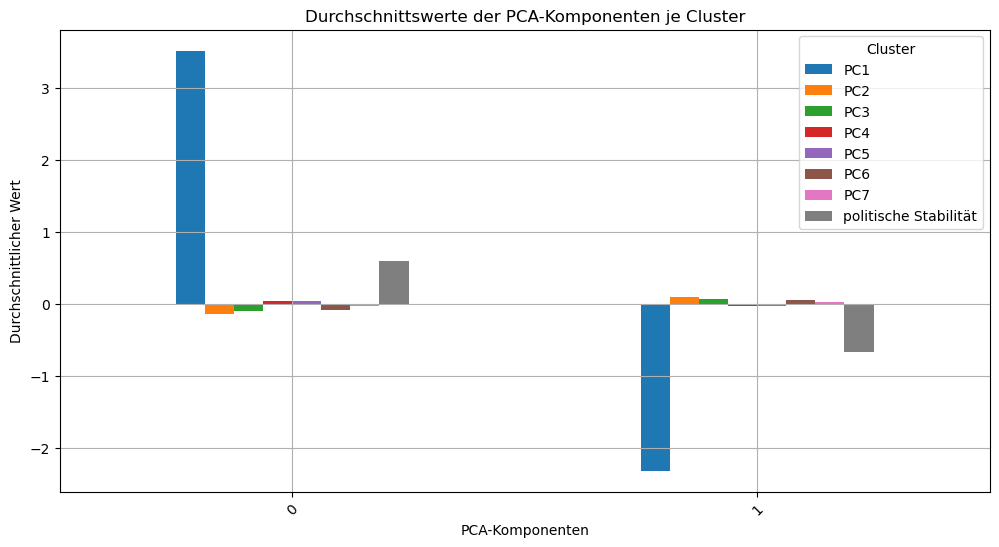

In [123]:
# Barplot erstellen
mittelwerte_Kmeans_pca.plot(kind="bar", figsize=(12, 6))
plt.title("Durchschnittswerte der PCA-Komponenten je Cluster")
plt.xlabel("PCA-Komponenten")
plt.ylabel("Durchschnittlicher Wert")
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.grid()
plt.show()

Um zu vertsehen, was die Mittelwerte aussagen müssen wir verstehen, welche Variablen in den Komponenten 1-7 dominieren. Dafür nutzt man die Loadings (siehe Aufgabe 5). Zur Erinnerung: PC1 erklärt 56% der Varianz.

PC1: Ein hoher PC1-Wert zeigt starke Institutionen, Rechtsstaatlichkeit und geringe Korruption; ein niedriger Wert das Gegenteil.

PC2: Ein hoher PC2-Wert deutet auf Staaten hin, die von aktiven demokratischen Bewegungen, einer freien Meinungsbildung und einer breiten politischen Teilnahme geprägt sind. Ein negativer Wert bedeutet das Gegenteil. 

PC3: Ein niedriger PC3-Wert deutet auf Länder mit hoher Fertilität, niedriger Lebenserwartung und geringer gesellschaftlicher Mobilisierung hin, was oft mit weniger entwickelten oder politisch instabileren Staaten in Verbindung gebracht wird. Ein positiver Wert bedeutet das Gegenteil. 

PC4: Ein hoher Wert in PC4 bedeutet, in diesen Ländern eine stärkere Teilnahme an staatlich organisierten Gruppen sowie zivilgesellschaftlichen Aktivitäten zufinden ist, die mit weniger Korruption einhergeht.

PC5: Ein hoher PC5-Wert steht für Länder, in denen politische Gewalt und Polarisierung besonders ausgeprägt sind. Diese Länder befinden sich vermutlich in einem Zustand tiefer politischer Fragmentierung oder sogar in einer Krise.
Ein niedriger PC5-Wert zeigt Länder mit stärkerer Einbindung der Bevölkerung in organisierte Strukturen, weniger politischer Gewalt und geringerer Polarisierung. 

PC6: Ein hoher PC6-Wert deutet auf Länder mit starkem Engagement in nicht-politischen zivilgesellschaftlichen Bereichen hin, begleitet von relativ hoher Lebenserwartung und möglicherweise schwächer ausgeprägter politischer Beteiligung. Es handelt sich um Gesellschaften mit sozialer Stabilität, aber ohne zwingend starke oder demokratisch legitimierte politische Institutionen.

PC7: Ein hoher PC7-Wert zeigt Staaten mit starker ideologischer Polarisierung innerhalb der Gesellschaft, oft trotz oder gerade wegen gut funktionierender Institutionen. Dies könnte auf „gespaltene Demokratien“ hinweisen – etwa reife Demokratien mit zunehmendem Populismus, Identitätspolitik oder Lagerbildung.
Ein niedriger PC7-Wert hingegen kennzeichnet Länder mit stärkerer autoritärer Kontrolle, weniger gesellschaftlicher Spaltung, aber auch geringerer öffentlicher Beteiligung und eher technokratischer oder repressiver Stabilität.

* Was bedeuten die Cluster? 

Cluster 0: ist ein Cluster von stabilen Demokratien mit starken Institutionen, niedriger Korruption, aber mäßigem zivilgesellschaftlichem Engagement und geringer politischer Mobilisierung. 

Cluster 1: ist ein Cluster von Ländern mit schwachen politischen Institutionen und einer eher starken Korruption, mit einer gleichzeitig eaktiveren Zivilgesellschaft und politischer Mobilisierung. Diese Staaten befinden sich eventuell in Transformationsprozessen oder in autoritären Phasen.

Hinsichtlih der Zielvariable lässt sich ein deutlicher Unterschied erkennen, der zusammen mit PC1 variiert.

# Zusammenfassende Schlussfolgerung bezüglich des vergleichs der Mittelwerte: 

Beide Clusteranalysen haben auf Basis ähnlicher ursprünglicher Variablen die Länder in mehr oder weniger gleiche Gruppen eingeteilt. 
Auch wenn die PCA Methode zuerst Eigenvektoren auf Basis von den ursprünglichen Variablen bildet sind die inhaltlichen bedeutungen der Variablen für die Einteilungen in die Cluster ähnlich. Wie man auch an dem Vergleich der Dateninstanzen sehen konnte. 

### plain data DBSCAN

In [127]:
from sklearn.cluster import DBSCAN

# Cluster mit DBSCAN  --> siehe: Hilfe zum Bestimmen der Parameter:
dbscan = DBSCAN(
    eps= 3,                # Radius 
    min_samples= 25,       # Mindestanzahl von Punkten im eps-Umkreis
    metric='minkowski',    # Distanzmaß (hier euklidische Distanz)
    metric_params=None,    # Zusätzliche Parameter für die Distanzfunktion (nicht genutzt)
    algorithm='auto',      # Algorithmus zur Suche
    leaf_size=50,          # Blattgröße für Baum-Strukturen zur Optimierung (relevant für große Datensätze)
    p= 1.5 ,               # Parameter für Minkowski-Metrik (nicht relevant bei 'euclidean') --> Je höher P desto stärker dominieren große Unterschied
    n_jobs=-1             
)

# DBSCAN auf standardisierten Daten X ausführen 
dbscan_clusters = dbscan.fit_predict(X)  # X ist der standardisierter Datensatz (Data_plain)

# Ausgabe Clusterlabels:
# -1 kennzeichnet Punkte, die als Rauschen (Noise) eingestuft wurden,
print(np.unique(dbscan_clusters))

[-1  0  1  2  3  4  5]


In [128]:
X_DBSCAN = pd.DataFrame(X, columns=Data_plain.columns, index=Data_plain.index)
X_DBSCAN["Cluster"] = dbscan_clusters  # Clusterlabels

# hinzufügen von politischer Stabilität 
X_DBSCAN["politische Stabilität"] = Data["politische Stabilität"]

# Vergleich der Mittelwerte je Feature und Cluster
cluster_means = X_DBSCAN.groupby("Cluster").mean()
cluster_means

,Liberale Demokratie (Index),Wahlen (Index),Meinungs- und Informationsfreiheit (Index),Gleicheit vor dem Gesetz und individuelle Freiheiten (Index),Zugang zur Justiz,Rechtsstaatlichkeit(Index),öffentliche Korruption,politische Korruption,Korruption der Exekutive,Fertilitätsrate,Lebenserwartung,politische Polarisierung,politische Gewalt,Versammlungsfreiheit,Massenmobilisierung,Autokratische Bewegungen,Demokratische Bewegungen,Beteiligung an staatlich organisierten Gruppen,Beteiligung an unabhängigen nicht-politischen Gruppen,Freiheit von Forschung und Lehre,politische Stabilität
Cluster,,,,,,,,,,,,,,,,,,,,,
-1,-0.703984,-0.724807,-0.718912,-0.652982,-0.529871,-0.518514,0.389516,0.348731,0.366579,0.178736,-0.374610,0.380648,0.273173,-0.795309,0.007864,0.616745,-0.069628,0.475109,-0.385341,-0.755274,-0.486097
0,0.321605,0.347822,0.372911,0.306802,0.247179,0.236352,-0.167219,-0.144925,-0.163031,-0.049370,0.115303,-0.098800,-0.067214,0.376250,0.061778,-0.246100,0.107589,-0.198867,0.197913,0.368307,-0.073553
1,-1.170121,-1.459756,-1.741954,-1.167210,-0.992601,-0.820843,0.246324,0.189957,0.126182,-0.728405,0.456112,-0.196979,-0.380443,-1.288541,0.134959,1.139001,-0.915778,1.481928,-0.045410,-1.289934,-0.307049
2,-1.097881,-1.625272,-1.988019,-0.376888,0.254485,0.130315,-0.334229,-0.581923,-0.393335,-0.183373,0.233107,-1.545828,-0.842450,-1.431617,-1.903588,-0.361040,-1.445419,-0.207882,-0.915922,-1.275931,0.863596
3,-1.261881,-1.214303,-1.618612,-1.402945,-1.501029,-1.524555,1.299877,1.324858,1.347975,-0.166287,-0.230401,-0.056524,-0.178849,-1.607510,-0.859841,0.524640,-0.793358,0.274590,-1.772596,-1.879553,-0.753463
4,-1.315762,-1.378707,-1.936080,-1.840102,-1.552591,-1.473045,1.092593,1.154860,1.343040,1.068377,-0.458496,0.837788,0.443040,-1.690748,-0.271344,2.217438,-1.056897,1.325025,-1.322071,-2.040313,-0.185457
5,-1.334528,-1.886046,-1.956173,-1.848384,-1.372020,-0.797181,0.447902,-0.136822,0.766136,0.031989,0.230678,-0.421526,-0.123870,-2.032165,-1.886585,-0.944719,-1.612542,-0.454170,-0.918702,-1.815121,-0.399720


Cluster 0: Cluster 0 ist ein großes CLuster, was sich entlang des Spektrums erstreckt.Es beinhaltet im Schnitt leicht überdurchschnittlich starke Demokratiewerte und leicht überdurchschnittliche  Freiheits‑ und Lebenswerte, eine geringe Korruption, eine  moderate Mobilisierung und insgesamt stabile Verhältnisse.
--> Ist meiner Meinung nach durch den Ketteneffekt verzerrt.

Cluster 1: besteht wahrscheinlich aus  Autokratien – schlechte liberale Werte, etwas Korruption, starke autokratische Bewegungen, etwas instabil.

Cluster 2: wahrscheinlich Repressive, aber gefestigte Regime – extrem niedrige Demokratiewerte, wenig Korruption, hohe Gewalt und Autokratie‑Mobilisierung, paradox positiv bei politischer Stabilität.

Cluster 3: sehr niedrige Freiheits‑ und Justizwerte, extrem hohe Korruption, wenig offene Gewalt, politisch fragil.

Cluster 4: schwache Institutionen, sehr hohe Massen‑ und Protestmobilisierung (auto‑ und demokratisch), etwas instabil.

Cluster 5:  schlechte DemokratieWerte, mäßige Korruption, kaum Mobilisierung oder Gewalt; politisch lethargisch und repressiv, recht instabil.

Die Cluster weisen interessante Eigenschaften auf. Diese sind jedoch mit Vorsicht zu genießen, da sich nicht allzu viele unterschiedliche Länder in den kleineren Clustern befinden.

### DBSCAN mit PCA

In [131]:
dbscan = DBSCAN(
    eps= 2.5,              # Radius 
    min_samples= 20,       # Mindestanzahl von Punkten im eps-Umkreis
    metric='minkowski',    # Distanzmaß (hier euklidische Distanz)
    metric_params=None,    # Zusätzliche Parameter für die Distanzfunktion (nicht genutzt)
    algorithm='auto',      # Algorithmus zur Suche
    leaf_size=50,          # Blattgröße für Baum-Strukturen zur Optimierung (relevant für große Datensätze)
    p= 1.5 ,               # Parameter für Minkowski-Metrik (nicht relevant bei 'euclidean') --> Je höher P desto stärker dominieren große Unterschied
    n_jobs=-1              # Nutzt alle verfügbaren CPU-Kerne für parallele Berechnung
)

# DBSCAN auf standardisierten Daten X ausführen 
dbscan_clusters2 = dbscan.fit_predict(data_pca)  # data_pca ist schon standardisiert 

# Ausgabe aller unterschiedlichen Clusterlabels:
# -1 kennzeichnet Punkte, die als Rauschen (Noise) eingestuft wurden,
print(np.unique(dbscan_clusters2))

[-1  0  1  2  3  4  5]


In [132]:
data_pca_DBSCAN = data_pca.copy()
data_pca_DBSCAN["Cluster"] = dbscan_clusters2 # Clusterlabels

# hinzufügen von politischer Stabilität 
data_pca_DBSCAN["politische Stabilität"] = Data["politische Stabilität"]

# Vergleich der Mittelwerte je Feature und Cluster
mittelwerte_DBSCAN_pca = data_pca_DBSCAN.groupby("Cluster").mean()
mittelwerte_DBSCAN_pca

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,politische Stabilität
Cluster,,,,,,,,
-1,-4.216431,-0.308958,0.195157,0.725761,1.651806,-0.911859,-0.576248,-1.639208
0,0.108371,0.102661,0.022286,-0.037751,0.014547,0.020563,0.006431,-0.174931
1,-6.508871,-3.857180,-2.468497,0.811934,-2.246757,-1.555826,-1.425306,-0.234750
2,-1.774674,-2.250687,-1.160580,0.644357,-0.591533,-0.603077,1.790810,0.211300
3,-2.681519,-2.474960,0.613540,2.799275,0.166577,-0.844854,0.243777,-0.443429
4,-5.349661,-4.307488,-0.383997,-0.237138,-1.833383,0.254307,-1.695132,0.077958
5,2.398212,-4.064962,-0.511509,1.809842,0.426131,0.134306,0.952368,1.269417


Ich möchte hier nicht auf alle PC Mittelwerte je Cluster eingehen. Nur auf PC1, da dieser 56 % der Varianz der Daten erklärt und damit besonders wichtig ist. PC1: Ein hoher PC1-Wert zeigt starke Institutionen, Rechtsstaatlichkeit und geringe Korruption; ein niedriger Wert das Gegenteil.

Cluster 0: Cluster Null erstreckt sich über fast das gesammte Spektrum. Es ist kein wirkliches Cluster, sondern ein Querschnitt der Restlichen Länder.

Ansonsten unterscheiden sich die Werte bezüglich PC1 stark, was auf große Unterschiede zwischen den Clustern hindeutet. Die Tatsache, dass die Cluster klein sind macht dies jedoch wahrscheinlicher. Bezüglich der Zielvariable gilt scheinbar nur, dass eine positiver PC1 Wert mit einer politischen Stabilität einher geht. Ein niedriger PC1- Wert jedoch nicht zwangsläufig mit einer sehr geringen politischen Stabilität.


### HAC ohne PCA

In [133]:
from sklearn import cluster
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster import hierarchy

# Clustern mit HAC
agg = cluster.AgglomerativeClustering(
        n_clusters = 2,        # Angabe wie viel Cluster ich am Ende erhalten möchte.  
        metric='manhattan',    # Distanzmaß
        linkage='average',     # Linkage‑Kriterium: Distanz zweier Cluster average = Mittelwert aller Punkt‑zu‑Punkt‑Distanzen
        compute_distances=True # speichert die Distanzen während des Merge‑Prozesses
                               #   → nötig, um später ein Dendrogramm zu zeichnen
)

Cluster_HAC = agg.fit_predict(X) # X = Data_plain standardisiert


X_HAC = pd.DataFrame(X, columns=Data_plain.columns, index=Data_plain.index)
X_HAC["Cluster"] =  Cluster_HAC # Clusterlabels

# hinzufügen von politischer Stabilität 
X_HAC["politische Stabilität"] = Data["politische Stabilität"]

# Vergleich der Mittelwerte je Feature und Cluster
mittelwerte_HAC = X_HAC.groupby("Cluster").mean()
mittelwerte_HAC

,Liberale Demokratie (Index),Wahlen (Index),Meinungs- und Informationsfreiheit (Index),Gleicheit vor dem Gesetz und individuelle Freiheiten (Index),Zugang zur Justiz,Rechtsstaatlichkeit(Index),öffentliche Korruption,politische Korruption,Korruption der Exekutive,Fertilitätsrate,Lebenserwartung,politische Polarisierung,politische Gewalt,Versammlungsfreiheit,Massenmobilisierung,Autokratische Bewegungen,Demokratische Bewegungen,Beteiligung an staatlich organisierten Gruppen,Beteiligung an unabhängigen nicht-politischen Gruppen,Freiheit von Forschung und Lehre,politische Stabilität
Cluster,,,,,,,,,,,,,,,,,,,,,
0,-0.697027,-0.659952,-0.523430,-0.599844,-0.589010,-0.674104,0.627555,0.634615,0.613436,0.393650,-0.398038,0.357917,0.459983,-0.565968,0.108183,0.454104,0.176608,0.46759,-0.269260,-0.530228,-0.674727
1,1.042506,0.987056,0.782866,0.897155,0.880951,1.008222,-0.938600,-0.949160,-0.917483,-0.588761,0.595324,-0.535317,-0.687973,0.846488,-0.161804,-0.679179,-0.264143,-0.69935,0.402717,0.793035,0.576470


Cluster 1 – Liberale Demokratien mit stabiler Ordnung Dieses Cluster zeigt stark positive Werte bei Demokratie, Rechtsstaatlichkeit, Meinungsfreiheit und Gleichheit vor dem Gesetz. Die Korruption ist deutlich negativ, was für ein hohes Maß an Integrität staatlicher Institutionen spricht. Die Lebenserwartung ist überdurchschnittlich, die Fertilitätsrate niedrig. Das ist typisch für entwickelte Länder. Politische Gewalt und Polarisierung sind gering, die Versammlungsfreiheit hoch. --> Aufgrund dieser Merkmale ist die politische Stabilität dieses Clusters hoch.

Cluster 0 – Autokratische, instabilere Systeme mit hoher Korruption Die Demokratiewerte sind stark negativ, ebenso Rechtsstaatlichkeit und bürgerliche Freiheiten. Gleichzeitig ist die Korruption in allen Formen erhöht. Die Lebenserwartung ist unterdurchschnittlich, die Fertilität höher. Politische Gewalt, Polarisierung und autokratische Bewegungen sind klar positiv ausgeprägt.

→ Aufgrund dieser Merkmale ist die politische Stabilität dieses CLusters niedriger

### HAC mit PCA

In [134]:
# Clustern mit HAC
agg = cluster.AgglomerativeClustering(
        n_clusters = 2,  # Angabe wie viel Cluster ich am Ende erhalten möchte.  
        metric='euclidean',    # Distanzmaß
        linkage='complete',     # Linkage‑Kriterium: Distanz zweier Cluster average = Mittelwert aller Punkt‑zu‑Punkt‑Distanzen
        compute_distances=True # speichert die Distanzen während des Merge‑Prozesses
                               #   → nötig, um später ein Dendrogramm zu zeichnen
)

Cluster_HAC2 = agg.fit_predict(data_pca) # standardisiert


# Ausgabe der Mittelwert + Zielvariable
data_pca_HAC2 = data_pca.copy()
data_pca_HAC2["Cluster"] = Cluster_HAC2
data_pca_HAC2["politische Stabilität"] = Data["politische Stabilität"]
cluster_means3 = data_pca_HAC2.groupby('Cluster').mean()
cluster_means3

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,politische Stabilität
Cluster,,,,,,,,
0,-2.407951,0.209068,-0.006680,-0.011336,-0.061417,0.072560,0.027664,-0.720260
1,3.148753,-0.273388,0.008735,0.014824,0.080312,-0.094884,-0.036175,0.541757


Hinsichtlich der Zielvariable und auch hinsichtlich PC1 lässt sich ein starker Unterschied zwischen den Clustern erkennen.
Auch hier erklärt PC1 die politische Stabilität gut.

# Korrelation mit der Zielvariable (politische Stabilität):

#### plain Data - generell

In [136]:
X_Korr= pd.DataFrame(X, columns=Data_plain.columns, index=Data_plain.index)

In [137]:
# hinzufügen von politischer Stabilität für die Korrelation. 
X_Korr["politische Stabilität"] = Data["politische Stabilität"]

In [139]:
# Korrelationen 
correlation1 = X_Korr.corr()["politische Stabilität"].drop("politische Stabilität")
correlation1

Liberale Demokratie (Index)                                     0.612404
Wahlen (Index)                                                  0.545407
Meinungs- und Informationsfreiheit (Index)                      0.343190
Gleicheit vor dem Gesetz und individuelle Freiheiten (Index)    0.645330
Zugang zur Justiz                                               0.649881
Rechtsstaatlichkeit(Index)                                      0.690315
öffentliche Korruption                                         -0.689218
politische Korruption                                          -0.718109
Korruption der Exekutive                                       -0.667066
Fertilitätsrate                                                -0.532793
Lebenserwartung                                                 0.471214
politische Polarisierung                                       -0.564798
politische Gewalt                                              -0.789834
Versammlungsfreiheit                               

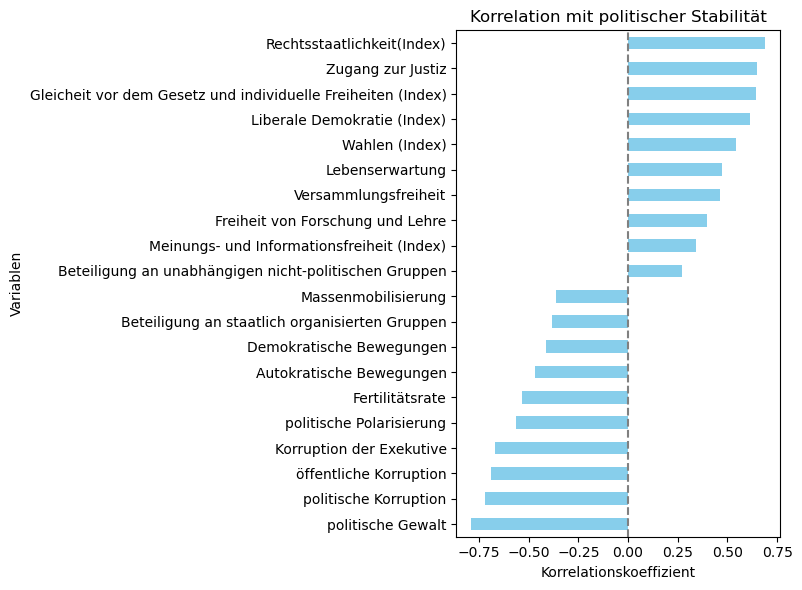

In [140]:
# Barplot horizontal
correlation1.sort_values().plot(kind='barh', figsize=(8, 6), color='skyblue')

plt.title('Korrelation mit politischer Stabilität')
plt.xlabel('Korrelationskoeffizient')
plt.ylabel('Variablen')
plt.axvline(0, color='gray', linestyle='--')  # Linie bei 0
plt.tight_layout()
plt.show()

* Diese Grafik zeigt, welche Variable die politische Stabilität am besten erklärt. 
Der stärkste Faktor scheint die politische Gewalt zu sein. Darauf folgen die variablen der politischen Korruption und die Variablen zur institutionellen Qualität (Rechtsstaat, liberale Demokratie, Gleichheit vor dem gesetz, Zugang zur Justiz)

* Ferner lässt sich erkennen, dass das Cluster funktioniert. Es zeigt eine starke Trennung zwischen den Gruppen, auch in bezug auf die politische Stabilität. 

### pca Data -- generell

In [141]:
# Dfs zusammenführen, indem die Spalte politische Stabilität ergänzt wird
merged = pd.concat([data_pca, Data[["politische Stabilität"]]], axis=1)

In [142]:
# Korrelationen 
correlation2 = merged.corr()["politische Stabilität"].drop("politische Stabilität")
correlation2

PC1    0.709008
PC2   -0.373419
PC3   -0.015217
PC4    0.123451
PC5   -0.194707
PC6   -0.045321
PC7    0.101802
Name: politische Stabilität, dtype: float64

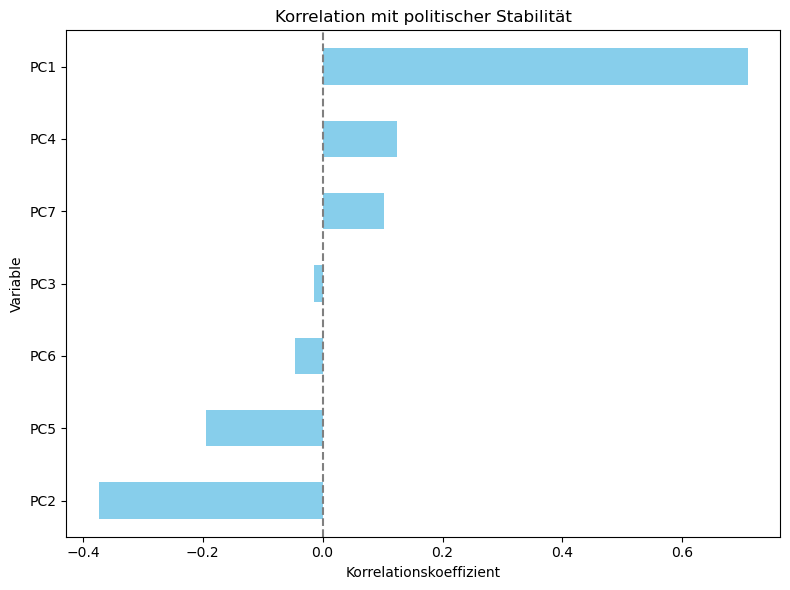

In [143]:
# Barplot horizontal
correlation2.sort_values().plot(kind='barh', figsize=(8, 6), color='skyblue')

plt.title('Korrelation mit politischer Stabilität')
plt.xlabel('Korrelationskoeffizient')
plt.ylabel('Variable')
plt.axvline(0, color='gray', linestyle='--')  # Linie bei 0
plt.tight_layout()
plt.show()

* PC1 ist der zentrale Treiber politischer Stabilität (stark positive Korrelation) --> starke Institutionen, wenig Korruption, starke Rechtsstaatlichkeit = hohe stabilität. 

* PC2 scheint auch relevant zu sein (mittlere negative Korrelation) --> soziale Unruhe oder Protestpotenzial = geringere Stabilität.

* PC3–PC7 tragen wenig bis gar nichts zur Erklärung der politischen Stabilität bei.

* Das Clustering funktioniert gut (aufgrund von PC1): Es trennt die Länder in zwei Gruppen, die sich deutlich in ihrer politischen Stabilität unterscheiden. Negativer Zusammenhang: Weil Cluster 0 stabile Länder enthält und mit 0 codiert ist. Cluster 1 ist mit 1 codiert. 

# Zusammenfassende Schlussfolgerung des Vergleichs mit der Korrelation zur Zielvariable

* Das Cluster ohne PCA hat den Vorteil, dass die Variablen direkt mit der Zielvariable korrelieren können. 
Wodurch ermittelt werden kann welche Variablen vermutlich den stärksten Einfluss auf die Zielvariable haben.  

* Schaut man sich jedoch die Korrelation der Cluster zur Zielvariable an, dann stellt man fest, dass das Cluster mit PCA minimal stärker mit der politischen Stabilität korreliert (0.635446 vs. 0.636220), was bedeutet, dass dieses Clustering auch minimal besser funktioniert hat. 

# Nr 3)

# Zusammenfassung der erzielten Ergebnisse
Zentrale Ergebnisse der Analyse:

* Hauptkomponentenanalyse (PCA) reduzierte die Vielzahl an Variablen auf sieben Hauptkomponenten, wobei PC1 mit 56 % der Varianz der mit Abstand wichtigste Faktor war. Insgesamt war der Unterschie zwischen der Nutzung von PCA und der Nichtnutzung jedoch nicht allzu groß.

* PC1 steht für starke Institutionen, Rechtsstaatlichkeit und geringe Korruption, was gleichzeitig die Kernelemente politischer Stabilität sind. 

* Ferner identifizierte die Clusteranalyse zwei Gruppen von Ländern (Sowohl Kmeans als auch HAC. DBSCAN hat nicht wirklich funktioniert):

Cluster 0: Länder mit stabilen, demokratischen Strukturen, geringer Korruption, aber mäßiger Mobilisierung.

Cluster 1: Länder mit schwächeren Institutionen, aber stärkerer zivilgesellschaftlicher Aktivität, höherer politischer Gewalt und höherer Korruption. Diese Länder waren zu Zeitpunkt der Datenerhebung mutmaßlich politisch instabil oder gefährdet. 

* Weiterhin zeigte PC2 (Demokratische Bewegungen & Meinungsfreiheit) eine negative Korrelation mit der politischen Stabilität --> Hinweis auf mögliche Protest- oder Unruherisiken.

* Die Politische Gewalt war die stärkste Einzelvariable zur Erklärung von Instabilität, gefolgt von Korruption und institutioneller Qualität (liberale Demokratie, Gleicheit vor dem Gesetz, faire und freie Wahlen etc).

* Mit HAC hätte man eventuell noch kleiner Cluster entdecken können. Die CLusterqualität wäre jedoch sehr schlecht gewesen. Die dominierenden Variablen wären jedoch ähnlich geblieben. 

# Vergleich mit dem ursprünglichen Plan (Pitch)

Die Analyse erfüllte die Hauptziele des ursprünglichen Projekts recht gut:

* Es wurden politische Risikomuster erkannt,
* Es wurden Schlüsselfaktoren der Instabilität identifiziert 
* Und es wurde ein Clusterstruktur gefunden welches stark mit der Zielgröße politischer Stabilität korreliert.

Gleichzeitig zeigte sich, dass nicht alle zivilgesellschaftlichen Aktivitäten ein Risiko darstellen, sondern in stabilen Demokratien auch Ausdruck gesunder Partizipation sein können – ein wichtiger, differenzierender Erkenntnisgewinn gegenüber der Ausgangshypothese.


# Nr. 4) 

Das Clustering generierte wertvolle Erkenntnisse darüber, welche Länder ein erhöhtes Risiko politischer Instabilität aufweisen. 

* Das Clustering teilt Länder zuverlässig in zwei Gruppen:

Stabil: starke Institutionen, geringe Korruption, hohe Rechtsstaatlichkeit.

Gefährdet/Instabil: schwache Institutionen, politische Gewalt, erhöhte zivilgesellschaftliche Spannung, erhöhte Korruption.

* Die Hauptfaktoren sind politisch beeinflussbar und konnten identifiziert werden (Korruption, Gewalt, demokratische Rechte) --> konkret beeinflussbar

* Um zu Erkennen ob ein Land auf eine Instabilität zusteuert, müssen die genannten Faktoren beobachtet werden, um Trends erkennen zu können. 

# Nr 5)

* Die Clusteranalysen reduzieren politische Realität auf zwei Gruppen, obwohl es oft viele Zwischentöne gibt (z. B. hybride Regime, fragile Demokratien). Außerdem ist jedes Land sehr individuell. Die Ergebnisse lassen sich nicht immer verallgemeinern. 

* Die Analyse basiert auf dem V-Dem-Datensatz, der von Expertenurteilen und Modellen abhängig ist. Deshalb spielt die Voreingenommenheit der Experten eine Rolle. 

* Die Daten und Analysen sind oft historisch, während politische Entwicklungen schnell verlaufen.

* es konnten keine spezifischen Veränderungen Variablen erkannt werden, die einen Trend einläuten. 



# Nr 6)

* Ich hätte mithilfe der Dendogramme beim Clustern mit HAC kleinere Gruppen von Ländern mit spezifischen Merkmalen identifizieren können. 

* Szenarienanalyse: Was passiert bei Veränderung einzelner Variablen?
Dadurch könnte beobachtet werden wie und warum sich ein Land von dem einen Cluster in das andere verschiebt. 

* Zeitreihenbasierte Stabilitätsprognose mit Recurrent Neural Networks:
Die politische Stabilität ist dynamisch. Solch ein odell könnte helfen, zeitliche Muster in der Entwicklung einzelner Länder zu erkennen und zukünftige Instabilität vorherzusagen.


* Integration externer Krisenindikatoren (z. B. Arbeitslosigkeit, Konflikte):
Wirtschaftliche oder geopolitische Schocks sind oft Trigger für Instabilität.

# Nr 7) 

Die angewandte Methodik liefert insgesamt solide und nachvollziehbare Ergebnisse, weist jedoch auch einige Einschränkungen auf, die bei der Interpretation berücksichtigt werden müssen. Die Hauptkomponentenanalyse (PCA) ermöglichte eine Reduktion der Datenkomplexität und identifizierte zentrale politische Dimensionen wie institutionelle Qualität, Korruption oder gesellschaftliche Mobilisierung. Dennoch basiert PCA auf linearen Zusammenhängen und kann dadurch komplexe, nicht-lineare Muster in politischen Entwicklungen nur begrenzt erfassen.

Die Clusteranalyse vereinfacht politische Realitäten, die häufig nicht binär sind. Die klare Trennung in zwei Ländergruppen bietet zwar analytische Klarheit, kann aber Übergangsstaaten oder hybride Regime nur unzureichend abbilden. Hinzu kommt, dass Ausreißer oder extreme Werte die Clusterbildung stark beeinflussen können.

Ein weiterer Schwachpunkt liegt in der Zielgrößenbeziehung: Die verwendete Zielvariable „politische Stabilität“ wurde nicht näher definiert (zumindest nicht im Codebook des V-Dem Institutes), wodurch unklar bleibt, wie unabhängig sie von den erklärenden Variablen ist.

Man hätte wahrscheinlich die zeitliche Entwicklung besser aufgreifen können. Ebenso war mein Vorgehen bei der Bearbeitung der Aufgaben unübersichtlich und ich musste mir oft erst klar werden, was ich eigentlich machen soll und was sinnvoll ist. Ich hätte mir für jede Aufgabe einen Ablaufplan schreiben können. Dadurch hätte ich die Methoden vielleicht intensiver ausführen können. 

Wahrscheinlich hätte man die Parameter, vorallem beim DBSCAN irgendwie auch besser einstellen können. Ich hätte auch mehr Methoden verwenden können, die die Clusterstruktur besser beschreiben. Auch methoden aus der Vorlesung. 

# Nr 8) 

Ich würde den Pitch jetzt gerne nochmal erstellen. Ich hätte inhaltlich einfach viel mehr gewusst. Auch hätte ich genauer beschreiben können, welche Clusteranalysen sinnhaft gewesen wären und welche nicht. So wie ich den Pitch erstellt habe, habe ich nur eine grobe Zielrichtung  genannt. Daher habe ich meine Ziele recht gut erreichen können.
Auch wenn ich keine länderspezifischen Trends entdecken konnte. 
Dies liegt allerdings auch daran, dass ich mich an die Aufgabenstellung gehalten habe. Dieses selbstgesteckte Ziel war jedoch nicht so wirklich mit der Aufgabenstellung des Clusterns zu vereinbaren. Zumindest nicht für meine Kenntnisse. Die Tatsache, dass ich gemeinsame Muster und Faktoren mit starkem Einfluss identifizieren konnte, zeigt jedoch, dass die Ziele ansonsten mit der Aufgabenstellung vereinbar waren und somit auch realistisch. 